# Análisis FBG: 5 Sensores - Fibra Poliamida POLY-1 (19/02/2026)

## 🔬 Contexto del Experimento

**Objetivo**: Caracterización de sensibilidad térmica y de presión de **sensores FBG** en una **nueva fibra de poliamida**.

**Fibra**: POLY-1 con coating de **poliamida** (diferente a las fibras utilizadas en experimentos anteriores).

⚠️ **Características del experimento**:
- Primera adquisición con esta fibra de poliamida
- Los plateaus empiezan aproximadamente a partir de las **16:00h**
- Se analizan **5 sensores FBG de longitudes de onda** (FBG-1, FBG-2, FBG-3, FBG-4, FBG-5)

✅ **NOTA IMPORTANTE**: Esta es una fibra **nueva (POLY-1)** con coating diferente. No se realizan comparaciones con otros experimentos.

Este notebook analiza **sensores FBG** (con 2 polarizaciones cada uno).
Calcula la **media de las polarizaciones** P y S para cada sensor y permite **definir plateaus manualmente**.


## 📋 Configuración:

- **8 RTDs**: 0-3 interiores (1=profundo, 2=medio, 4=superior, 3=superficial), 4-5 vacíos, 6-7 cápsula fibra

- **5 FBGs**: FBG-1, FBG-2, FBG-3, FBG-4, FBG-5 (cada uno con polarización P y S)

- **Análisis**: Media de polarizaciones vs temperatura y presión

- **Plateaus**: Definición manual por presión (empiezan ~16:00h)

- **Acceso a datos**: XRootD remoto vía uproot (no requiere montar /eos/ localmente en lxplus)

## 💡 Notas sobre el flujo de trabajo:

1. **Visualización de plateaus**: La celda justo antes de la sección 6.2 muestra gráficos superpuestos con líneas verticales marcando los plateaus. Para ver estas líneas correctamente, debes **ejecutar primero la sección 6.3** (definición de plateaus) y **luego re-ejecutar la celda de visualización**.

2. **Evolución temporal completa**: La **Sección 7** al final del notebook muestra todo el rango temporal disponible, permitiendo verificar visualmente el TIME_SHIFT de +2 horas aplicado a los datos de wavelength. Puedes filtrar opcionalmente por rango temporal dentro de esa celda.

3. **Datos de presión**: ✅ En esta adquisición los datos de presión funcionan correctamente y se utilizan para definir los plateaus.

## 1️⃣ Importar Librerías

In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /usr/bin/python3.11
Python versión: 3.11.13 (main, Jan 16 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-11)]
✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

In [3]:
# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Archivo de datos para la fibra de poliamida POLY-1
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260219.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
# Los picos tienen un desfase de +2h respecto a temperatura
TIME_SHIFT = datetime.timedelta(hours=2)  # ✅ Shift confirmado para este dataset

print(f"📂 Cargando archivo ROOT para fibra POLY-1: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Verificar que el archivo existe
import os
if not os.path.exists(filepath):
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    raise FileNotFoundError(f"El archivo {filepath} no existe")

# Verificar tamaño del archivo
file_size = os.path.getsize(filepath)
print(f"📊 Tamaño del archivo: {file_size / (1024**2):.2f} MB")

if file_size < 1000:  # Menos de 1 KB es sospechoso
    print(f"⚠️  ADVERTENCIA: El archivo parece muy pequeño ({file_size} bytes)")
    print(f"   Puede estar corrupto o vacío")

# Cargar datos del archivo ROOT
try:
    print("\n🔄 Abriendo archivo ROOT...")
    file = uproot.open(filepath)
    print("✅ Archivo ROOT abierto correctamente")
    
    # Mostrar estructura del archivo
    print("\n📋 Estructura del archivo ROOT:")
    print(f"   Keys disponibles: {file.keys()}")
    
    # Este archivo tiene estructura diferente: 'peak', 'temp', 'press' en lugar de 'FBG_data'
    print(f"\n🌳 Cargando TTrees individuales...")
    
    # Cargar cada TTree por separado
    tree_peak = file["peak"]
    tree_temp = file["temp"]
    tree_press = file["press"]
    
    print(f"   ✅ TTree 'peak' cargado: {tree_peak.num_entries} entradas")
    print(f"   ✅ TTree 'temp' cargado: {tree_temp.num_entries} entradas")
    print(f"   ✅ TTree 'press' cargado: {tree_press.num_entries} entradas")
    
    print(f"\n   Branches en 'peak': {tree_peak.keys()}")
    print(f"   Branches en 'temp': {tree_temp.keys()}")
    print(f"   Branches en 'press': {tree_press.keys()}")
    
    # Extraer datos en arrays de NumPy
    print("\n📦 Extrayendo datos a arrays NumPy...")
    data_peak = tree_peak.arrays(library="np")
    data_temp = tree_temp.arrays(library="np")
    data_press = tree_press.arrays(library="np")
    
    # Combinar en un solo diccionario para compatibilidad con el resto del código
    data = {}
    
    # Agregar datos de wavelength (picos)
    for key in data_peak.keys():
        data[key] = data_peak[key]
    
    # Agregar datos de temperatura
    for key in data_temp.keys():
        data[key] = data_temp[key]
    
    # Agregar datos de presión
    for key in data_press.keys():
        data[key] = data_press[key]
    
    print(f"\n✅ Datos extraídos y combinados correctamente")
    print(f"   Total de branches: {len(data.keys())}")
    print(f"   Keys disponibles: {list(data.keys())}")

except FileNotFoundError:
    print(f"\n❌ ERROR CRÍTICO: No se puede acceder al archivo")
    print(f"   Ruta: {filepath}")
    print(f"   Verifica que:")
    print(f"   1. Estás ejecutando desde lxplus")
    print(f"   2. El archivo existe en /eos/")
    print(f"   3. Tienes permisos de lectura")
    raise
except Exception as e:
    print(f"\n❌ ERROR al cargar datos: {e}")
    print(f"   Tipo de error: {type(e).__name__}")
    import traceback
    traceback.print_exc()
    raise

# Verificar que tenemos los datos esperados
print(f"\n🔍 Verificando datos cargados...")
print(f"   Keys totales: {len(data.keys())}")

# Extraer timestamps
try:
    # En este archivo: peak tiene timestamps 2D (medidas, polarizaciones)
    # Usar la primera polarización para los timestamps
    time_wavelength_raw = data_peak["t"][:, 0]  # Timestamps wavelength (primera polarización)
    time_temp_raw = data_temp["t"]  # Timestamps de temperatura (1D)
    time_press_raw = data_press["t"]  # Timestamps de presión (1D)
    
    print(f"\n⏰ Timestamps extraídos:")
    print(f"   Wavelength: {len(time_wavelength_raw)} puntos")
    print(f"   Temperature: {len(time_temp_raw)} puntos")
    print(f"   Pressure: {len(time_press_raw)} puntos")
    
    time_wavelength = np.array([datetime.datetime.fromtimestamp(float(t)) for t in time_wavelength_raw])
    time_temp = np.array([datetime.datetime.fromtimestamp(float(t)) for t in time_temp_raw])
    time_press = np.array([datetime.datetime.fromtimestamp(float(t)) for t in time_press_raw])
    
    print(f"\n📅 Rango temporal (wavelength):")
    print(f"   Inicio: {time_wavelength[0]}")
    print(f"   Fin: {time_wavelength[-1]}")
    print(f"   Duración: {time_wavelength[-1] - time_wavelength[0]}")
    
    print(f"\n📅 Rango temporal (temperatura):")
    print(f"   Inicio: {time_temp[0]}")
    print(f"   Fin: {time_temp[-1]}")
    print(f"   Duración: {time_temp[-1] - time_temp[0]}")
    
    print(f"\n📅 Rango temporal (presión):")
    print(f"   Inicio: {time_press[0]}")
    print(f"   Fin: {time_press[-1]}")
    print(f"   Duración: {time_press[-1] - time_press[0]}")
    
    # APLICAR TIME_SHIFT SOLO A WAVELENGTH
    time_wavelength_shifted = time_wavelength + TIME_SHIFT
    print(f"\n✅ TIME_SHIFT aplicado a wavelength (+{TIME_SHIFT.total_seconds()/3600:.1f}h)")
    print(f"   Nuevo inicio wavelength: {time_wavelength_shifted[0]}")
    print(f"   Nuevo fin wavelength: {time_wavelength_shifted[-1]}")
    
except KeyError as e:
    print(f"\n❌ ERROR: No se encontró la rama de tiempo esperada: {e}")
    print(f"   Ramas disponibles: {list(data.keys())}")
    raise
except Exception as e:
    print(f"\n❌ ERROR al procesar timestamps: {e}")
    raise

print(f"\n" + "="*60)
print("🎉 DATOS CARGADOS EXITOSAMENTE - Fibra POLY-1")
print("="*60)

📂 Cargando archivo ROOT para fibra POLY-1: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260219.root
⏱️  TIME_SHIFT configurado: 2.0 horas
📊 Tamaño del archivo: 61.90 MB

🔄 Abriendo archivo ROOT...
✅ Archivo ROOT abierto correctamente

📋 Estructura del archivo ROOT:
   Keys disponibles: ['peak;4', 'press;2', 'temp;2']

🌳 Cargando TTrees individuales...
   ✅ TTree 'peak' cargado: 774875 entradas
   ✅ TTree 'temp' cargado: 3068 entradas
   ✅ TTree 'press' cargado: 6097 entradas

   Branches en 'peak': ['t', 'wav', 'sweep', 'ch', 'pos']
   Branches en 'temp': ['t', 'temp']
   Branches en 'press': ['t', 'press']

📦 Extrayendo datos a arrays NumPy...

✅ Datos extraídos y combinados correctamente
   Total de branches: 7
   Keys disponibles: ['t', 'wav', 'sweep', 'ch', 'pos', 'temp', 'press']

🔍 Verificando datos cargados...
   Keys totales: 7

⏰ Timestamps extraídos:
   Wavelength: 774875 puntos
   Temperature: 3068 puntos
   Pressure: 6097 puntos

📅 Rango temporal (wavelength):
  

### 📊 Visualización de Presión y Temperatura

✅ **En esta adquisición los datos de presión funcionan correctamente**. Este plot muestra la evolución de presión y temperatura durante el experimento.

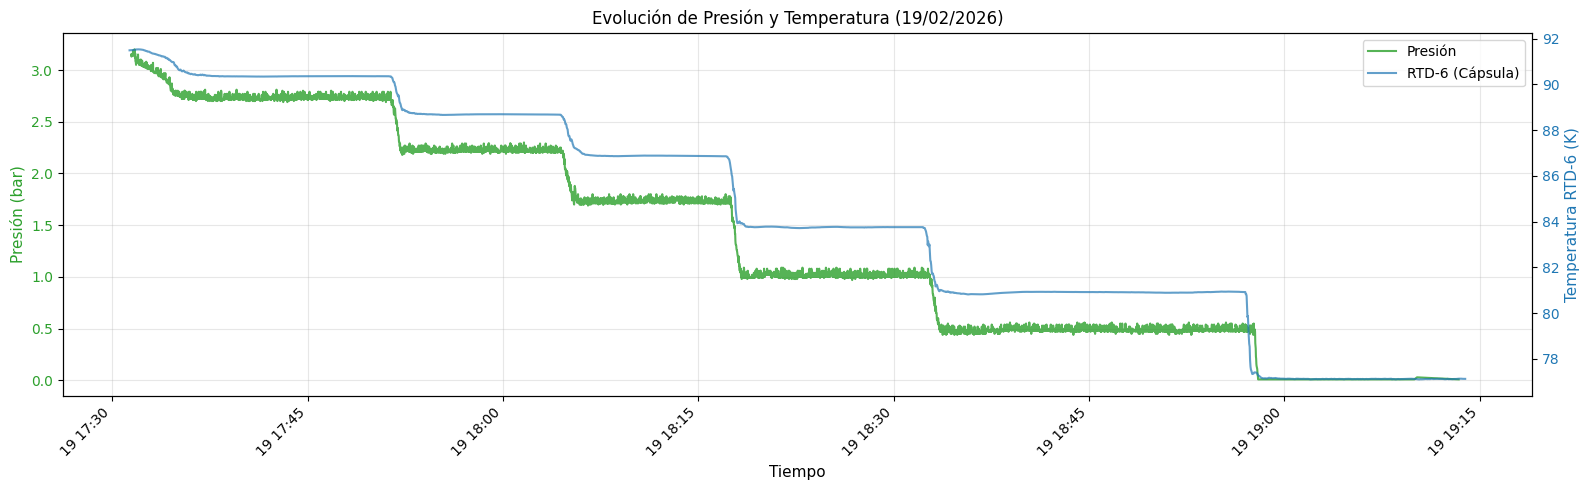


📊 Estadísticas de presión:
   Rango: [0.01, 3.20] bar
   Media: 1.57 bar
   Std: 0.899 bar
   Puntos válidos: 5,162
   Rango temporal: 17:31 - 19:13

📊 Estadísticas de temperatura (RTD-6):
   Rango: [77.10, 91.54] K
   Media: 84.37 K
   Std: 4.713 K
   Puntos válidos: 3,068


In [4]:
# Plot de presión y temperatura superpuestos
fig, ax1 = plt.subplots(1, 1, figsize=(16, 5))

# Extraer datos de presión
press_raw = data_press["press"]
if len(press_raw.shape) > 1:
    press_data_plot = press_raw[:, 0]
else:
    press_data_plot = press_raw

# Extraer times de presión
times_press = time_press

# Temperatura (RTD-6 - cápsula fibra)
rtd_ref_idx_preview = 6
temp_raw = data_temp["temp"]
temp_preview = temp_raw[:, rtd_ref_idx_preview]
times_temp = time_temp

# Filtrar valores positivos (usar todo el rango disponible)
press_valid_mask = (press_data_plot > 0)
times_press_valid = times_press[press_valid_mask]
press_valid = press_data_plot[press_valid_mask]

mask_temp_valid = (temp_preview > 0)
times_temp_valid = times_temp[mask_temp_valid]
temp_valid = temp_preview[mask_temp_valid]

# Eje izquierdo: Presión
color_press = 'tab:green'
ax1.set_xlabel('Tiempo', fontsize=11)
ax1.set_ylabel('Presión (bar)', fontsize=11, color=color_press)
if len(press_valid) > 0:
    ax1.plot(times_press_valid, press_valid, color=color_press, linewidth=1.5, alpha=0.8, label='Presión')
    ax1.tick_params(axis='y', labelcolor=color_press)
else:
    print("⚠️ No hay datos válidos de presión")

# Eje derecho: Temperatura
ax2 = ax1.twinx()
color_temp = 'tab:blue'
ax2.set_ylabel('Temperatura RTD-6 (K)', fontsize=11, color=color_temp)
if len(temp_valid) > 0:
    ax2.plot(times_temp_valid, temp_valid, color=color_temp, linewidth=1.5, alpha=0.7, label='RTD-6 (Cápsula)')
    ax2.tick_params(axis='y', labelcolor=color_temp)

# Título y grid
ax1.set_title(f'Evolución de Presión y Temperatura (19/02/2026)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Leyendas combinadas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

# Rotar etiquetas del eje X
for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.tight_layout()
plt.show()

if len(press_valid) > 0:
    print(f"\n📊 Estadísticas de presión:")
    print(f"   Rango: [{np.min(press_valid):.2f}, {np.max(press_valid):.2f}] bar")
    print(f"   Media: {np.mean(press_valid):.2f} bar")
    print(f"   Std: {np.std(press_valid):.3f} bar")
    print(f"   Puntos válidos: {len(press_valid):,}")
    print(f"   Rango temporal: {times_press_valid[0].strftime('%H:%M')} - {times_press_valid[-1].strftime('%H:%M')}")

if len(temp_valid) > 0:
    print(f"\n📊 Estadísticas de temperatura (RTD-6):")
    print(f"   Rango: [{np.min(temp_valid):.2f}, {np.max(temp_valid):.2f}] K")
    print(f"   Media: {np.mean(temp_valid):.2f} K")
    print(f"   Std: {np.std(temp_valid):.3f} K")
    print(f"   Puntos válidos: {len(temp_valid):,}")

## 3️⃣ Filtrar Rango Temporal

In [5]:
# 📊 Número de sensores FBG a analizar
num_sensores = 5  # Este experimento tiene 5 sensores FBG

# Extraer wavelengths y calcular media de polarizaciones
# Estructura de wav: (n_medidas, 2_polarizaciones, 5_sensores)
wav_raw = data_peak["wav"]

# wav_raw ya tiene forma (n_medidas, 2, num_sensores)
# Necesitamos reordenarlo a (n_medidas, num_sensores, 2) para media
wav_reshaped = np.transpose(wav_raw, (0, 2, 1))  # (n_medidas, num_sensores, 2_pol)

# Calcular media entre polarizaciones para cada sensor
wav_mean = np.mean(wav_reshaped, axis=2)  # (n_medidas, num_sensores)

# Extraer arrays de temperatura (8 RTDs)
temp_raw = data_temp["temp"]

# Crear array de tiempos wavelength (ya con shift aplicado) para compatibilidad
times_all = time_wavelength_shifted

# Crear array de tiempos temperatura (sin shift)
times_temp = time_temp

# Crear array de tiempos presión (sin shift)
times_press = time_press

# Datos de presión
press_raw = data_press["press"]

# press_raw tiene forma (n_medidas, 1) - extraer primera columna
if len(press_raw.shape) > 1:
    press_data_plot = press_raw[:, 0]
else:
    press_data_plot = press_raw
    
print(f"✅ Datos de presión cargados: {len(press_data_plot):,} puntos")

print(f"\n📊 Resumen de datos cargados:")
print(f"   Wavelength (media pol): {wav_mean.shape} = {wav_mean.shape[0]:,} medidas × {num_sensores} sensores")
print(f"   Temperatura: {temp_raw.shape} = {temp_raw.shape[0]:,} medidas × 8 RTDs")
print(f"   Presión: {len(press_data_plot):,} medidas")
print(f"   Timestamps wavelength: {len(times_all):,}")
print(f"   Timestamps temperatura: {len(times_temp):,}")
print(f"   Timestamps presión: {len(times_press):,}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
use_full_range = True  # Cambiar a False para rango específico

if use_full_range:
    t_inicio = times_all[0]
    t_fin = times_all[-1]
else:
    fecha = datetime.date(2026, 2, 19)
    t_inicio = datetime.datetime.combine(fecha, datetime.time(17, 30))
    t_fin = datetime.datetime.combine(fecha, datetime.time(21, 15))

# Filtrar wavelength (tiene TIME_SHIFT aplicado)
mask_time = (times_all >= t_inicio) & (times_all <= t_fin)
times_filtered = times_all[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar temperatura
mask_time_temp = (times_temp >= t_inicio) & (times_temp <= t_fin)
temp_filtered = temp_raw[mask_time_temp]
times_temp_filtered = times_temp[mask_time_temp]

# Filtrar presión
mask_time_press = (times_press >= t_inicio) & (times_press <= t_fin)
press_filtered = press_data_plot[mask_time_press]
times_press_filtered = times_press[mask_time_press]

print(f"\n✅ Rango seleccionado: {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"   Puntos wavelength: {len(times_filtered):,}")
print(f"   Puntos temperatura: {len(times_temp_filtered):,}")
print(f"   Puntos presión: {len(times_press_filtered):,}")
if len(times_filtered) == 0:
    print(f"\n⚠️  Sin datos en el rango. Activa 'use_full_range = True' o ajusta t_inicio/t_fin.")

✅ Datos de presión cargados: 6,097 puntos

📊 Resumen de datos cargados:
   Wavelength (media pol): (774875, 5) = 774,875 medidas × 5 sensores
   Temperatura: (3068, 8) = 3,068 medidas × 8 RTDs
   Presión: 6,097 medidas
   Timestamps wavelength: 774,875
   Timestamps temperatura: 3,068
   Timestamps presión: 6,097

✅ Rango seleccionado: 2026-02-19 17:32 - 19:15
   Puntos wavelength: 774,875
   Puntos temperatura: 3,042
   Puntos presión: 6,052


## 4️⃣ Análisis de Temperatura (8 RTDs)

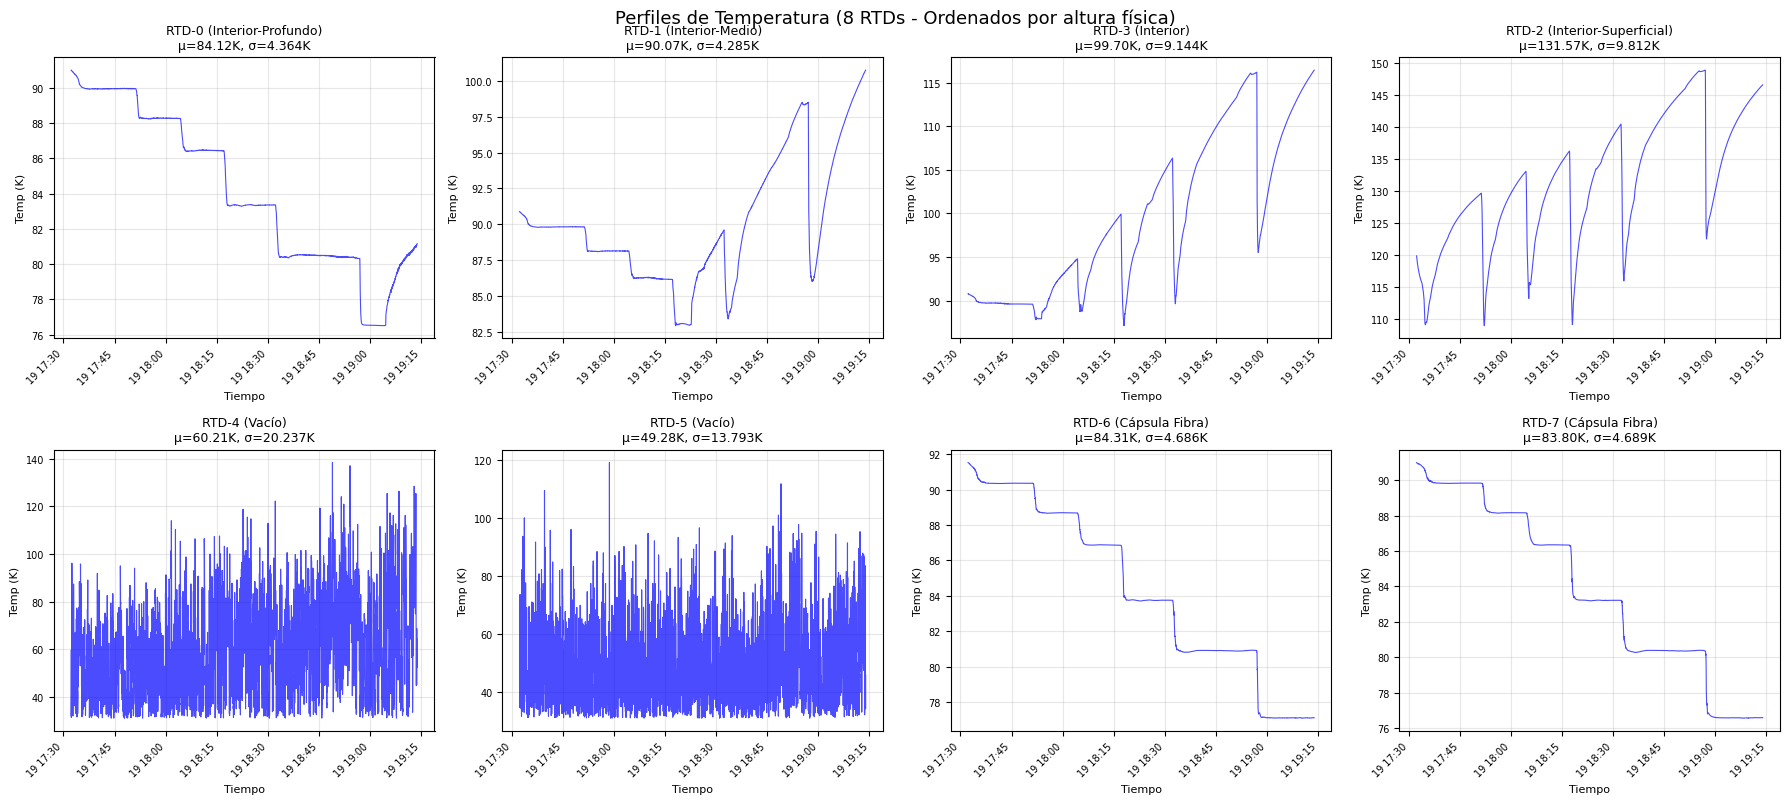


📊 Estadísticas (ordenados por altura física):
RTD-0 (Interior-Profundo)     : μ= 84.12K  σ= 4.364K
RTD-1 (Interior-Medio)        : μ= 90.07K  σ= 4.285K
RTD-3 (Interior)              : μ= 99.70K  σ= 9.144K
RTD-2 (Interior-Superficial)  : μ=131.57K  σ= 9.812K
RTD-4 (Vacío)                 : μ= 60.21K  σ=20.237K
RTD-5 (Vacío)                 : μ= 49.28K  σ=13.793K
RTD-6 (Cápsula Fibra)         : μ= 84.31K  σ= 4.686K
RTD-7 (Cápsula Fibra)         : μ= 83.80K  σ= 4.689K


In [6]:
# Configuración RTDs en orden de altura física (de abajo arriba en la vasija)
rtd_sensors_ordered = [
    (0, "RTD-0 (Interior-Profundo)"),      # Más cercano al suelo
    (1, "RTD-1 (Interior-Medio)"),         # Medio
    (3, "RTD-3 (Interior)"),               # Siguiente altura
    (2, "RTD-2 (Interior-Superficial)"),   # Más externo/superficial
    (4, "RTD-4 (Vacío)"),                  # Vacío
    (5, "RTD-5 (Vacío)"),                  # Vacío
    (6, "RTD-6 (Cápsula Fibra)"),          # Dentro de cápsula
    (7, "RTD-7 (Cápsula Fibra)")           # Dentro de cápsula
]

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (sensor_idx, sensor_name) in enumerate(rtd_sensors_ordered):
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    times_valid = times_temp_filtered[mask_valid]
    temp_valid = temp_sensor[mask_valid]
    
    if len(temp_valid) > 0:
        axes[idx].plot(times_valid, temp_valid, 'b-', linewidth=0.8, alpha=0.7)
        axes[idx].set_title(f"{sensor_name}\nμ={np.mean(temp_valid):.2f}K, σ={np.std(temp_valid):.3f}K", fontsize=9)
        axes[idx].set_xlabel('Tiempo', fontsize=8)
        axes[idx].set_ylabel('Temp (K)', fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(labelsize=7)
        for label in axes[idx].get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.suptitle('Perfiles de Temperatura (8 RTDs - Ordenados por altura física)', fontsize=13, y=1.00)
plt.show()

print("\n📊 Estadísticas (ordenados por altura física):")
for sensor_idx, sensor_name in rtd_sensors_ordered:
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    temp_valid = temp_sensor[mask_valid]
    if len(temp_valid) > 0:
        print(f"{sensor_name:30s}: μ={np.mean(temp_valid):6.2f}K  σ={np.std(temp_valid):6.3f}K")

## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [7]:
# ✅ CONFIGURACIÓN: 4 sensores FBG completos
# 4 sensores × 2 polarizaciones = 8 canales
# Índices 0-based: sensor 0, 1, 2, 3 (Python indexing)
fbg_config = [
    {"pol": 0, "sensor": 0, "label": "FBG-1-P"},
    {"pol": 1, "sensor": 0, "label": "FBG-1-S"},
    {"pol": 0, "sensor": 1, "label": "FBG-2-P"},
    {"pol": 1, "sensor": 1, "label": "FBG-2-S"},
    {"pol": 0, "sensor": 2, "label": "FBG-3-P"},
    {"pol": 1, "sensor": 2, "label": "FBG-3-S"},
    {"pol": 0, "sensor": 3, "label": "FBG-4-P"},
    {"pol": 1, "sensor": 3, "label": "FBG-4-S"},
]

print(f"✅ Configurados {len(fbg_config)} canales FBG (4 sensores × 2 polarizaciones)")
print(f"💡 Se verificará si FBG-4 tiene datos válidos en este dataset")

✅ Configurados 8 canales FBG (4 sensores × 2 polarizaciones)
💡 Se verificará si FBG-4 tiene datos válidos en este dataset


### 5.2 Filtrado Wavelength (μ±3σ)

In [8]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0, use_robust=True):
    """
    Filtra wavelength usando método μ±3σ o método robusto basado en mediana (MAD)
    
    Parameters:
    -----------
    wav_data : array
        Datos de wavelength a filtrar
    timestamps : array
        Timestamps correspondientes
    sigma_threshold : float
        Número de sigmas (o MADs) para el threshold
    use_robust : bool
        Si True, usa MAD (Median Absolute Deviation) en lugar de std
    """
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    if use_robust:
        # Método robusto: usa MEDIANA y MAD (más resistente a outliers)
        median_wav = np.median(wav_positive)
        mad = np.median(np.abs(wav_positive - median_wav))
        # Convertir MAD a escala comparable con std (factor 1.4826)
        sigma_equiv = 1.4826 * mad
        
        threshold_min = median_wav - sigma_threshold * sigma_equiv
        threshold_max = median_wav + sigma_threshold * sigma_equiv
        
        # Filtrar usando los thresholds robustos
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
        
        # Calcular estadísticas finales sobre datos filtrados
        wav_filtered = wav_data[mask_filtered]
        mean_wav = np.mean(wav_filtered)
        std_wav = np.std(wav_filtered)
    else:
        # Método clásico: μ±3σ
        mean_wav = np.mean(wav_positive)
        std_wav = np.std(wav_positive)
        threshold_min = mean_wav - sigma_threshold * std_wav
        threshold_max = mean_wav + sigma_threshold * std_wav
        
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }

# DIAGNÓSTICO: Verificar forma y valores de los sensores
print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")

# Diagnóstico por sensor (todos los sensores: 0, 1, 2, 3)
print(f"\n🔍 Diagnóstico de valores por sensor (FBG-1, FBG-2, FBG-3, FBG-4):")
for sensor_idx in range(4):  # 0, 1, 2, 3 (incluye FBG-4)
    for pol_idx in range(2):
        pol_name = "P" if pol_idx == 0 else "S"
        sensor_data = wav_filtered[:, pol_idx, sensor_idx]
        n_positive = np.sum(sensor_data > 0)
        if n_positive > 0:
            min_val = np.min(sensor_data[sensor_data > 0])
            max_val = np.max(sensor_data)
            mean_val = np.mean(sensor_data[sensor_data > 0])
        else:
            min_val = max_val = mean_val = 0
        
        print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2f}, {max_val:.2f}] nm, μ={mean_val:.2f} nm")

# Procesar todos los canales configurados (incluye FBG-4)
# 🔧 CONFIGURACIÓN: Elige el método de filtrado
USE_ROBUST_FILTERING = True  # True = MAD robusto, False = μ±3σ clásico
SIGMA_THRESHOLD = 3.0  # Ajusta este valor si quieres filtrado más o menos estricto (2.5-4.0)

print(f"\n⚙️  Método de filtrado: {'ROBUSTO (MAD)' if USE_ROBUST_FILTERING else 'CLÁSICO (μ±3σ)'}")
print(f"⚙️  Threshold: ±{SIGMA_THRESHOLD}{'×MAD' if USE_ROBUST_FILTERING else 'σ'}")

fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # (time, pol, sensor)
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data(
        wav_data, times_filtered, 
        sigma_threshold=SIGMA_THRESHOLD,
        use_robust=USE_ROBUST_FILTERING
    )

print("\n✅ Filtrado completado (4 sensores procesados)")
print(f"\n{'Sensor':<12} {'Mean (nm)':<12} {'Std (nm)':<12} {'N válidos'}")
print("="*60)
for label, data in fbg_filtered_data.items():
    print(f"{label:<12} {data['mean']:<12.6f} {data['std']:<12.6f} {data['n_valid']}")

🔍 Forma de wav_filtered: (774875, 2, 5)
   Dimensiones: (time=774875, pol=2, sensor=5)

🔍 Diagnóstico de valores por sensor (FBG-1, FBG-2, FBG-3, FBG-4):
   FBG-1-P:  774875 pts > 0, range=[0.00, 0.00] nm, μ=0.00 nm
   FBG-1-S:  774875 pts > 0, range=[0.00, 0.00] nm, μ=0.00 nm
   FBG-2-P:  774875 pts > 0, range=[0.00, 0.00] nm, μ=0.00 nm
   FBG-2-S:  774875 pts > 0, range=[0.00, 0.00] nm, μ=0.00 nm
   FBG-3-P:  774875 pts > 0, range=[0.00, 0.00] nm, μ=0.00 nm
   FBG-3-S:  774875 pts > 0, range=[0.00, 0.00] nm, μ=0.00 nm
   FBG-4-P:  774875 pts > 0, range=[0.00, 0.00] nm, μ=0.00 nm
   FBG-4-S:  774875 pts > 0, range=[0.00, 0.00] nm, μ=0.00 nm

⚙️  Método de filtrado: ROBUSTO (MAD)
⚙️  Threshold: ±3.0×MAD

✅ Filtrado completado (4 sensores procesados)

Sensor       Mean (nm)    Std (nm)     N válidos
FBG-1-P      0.000002     0.000000     526314
FBG-1-S      0.000002     0.000000     499206
FBG-2-P      0.000002     0.000000     448082
FBG-2-S      0.000002     0.000000     423340
FBG-3-

### 5.3 Calcular Media de Polarizaciones

In [9]:
# Calcular media P+S para cada sensor (4 sensores: 1, 2, 3, 4)
fbg_mean_data = {}

for sensor_num in [1, 2, 3, 4]:  # Todos los sensores (incluye FBG-4)
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p])
    times_s_sec = np.array([t.timestamp() for t in times_s])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para todos los sensores")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6f} {data['std']:<15.6f} {data['n_valid']}")

✅ Medias calculadas (P+S)/2 para todos los sensores

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      0.000002        0.000000        526314
FBG-2-Mean      0.000002        0.000000        448082
FBG-3-Mean      0.000002        0.000000        552140
FBG-4-Mean      0.000002        0.000000        426332


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

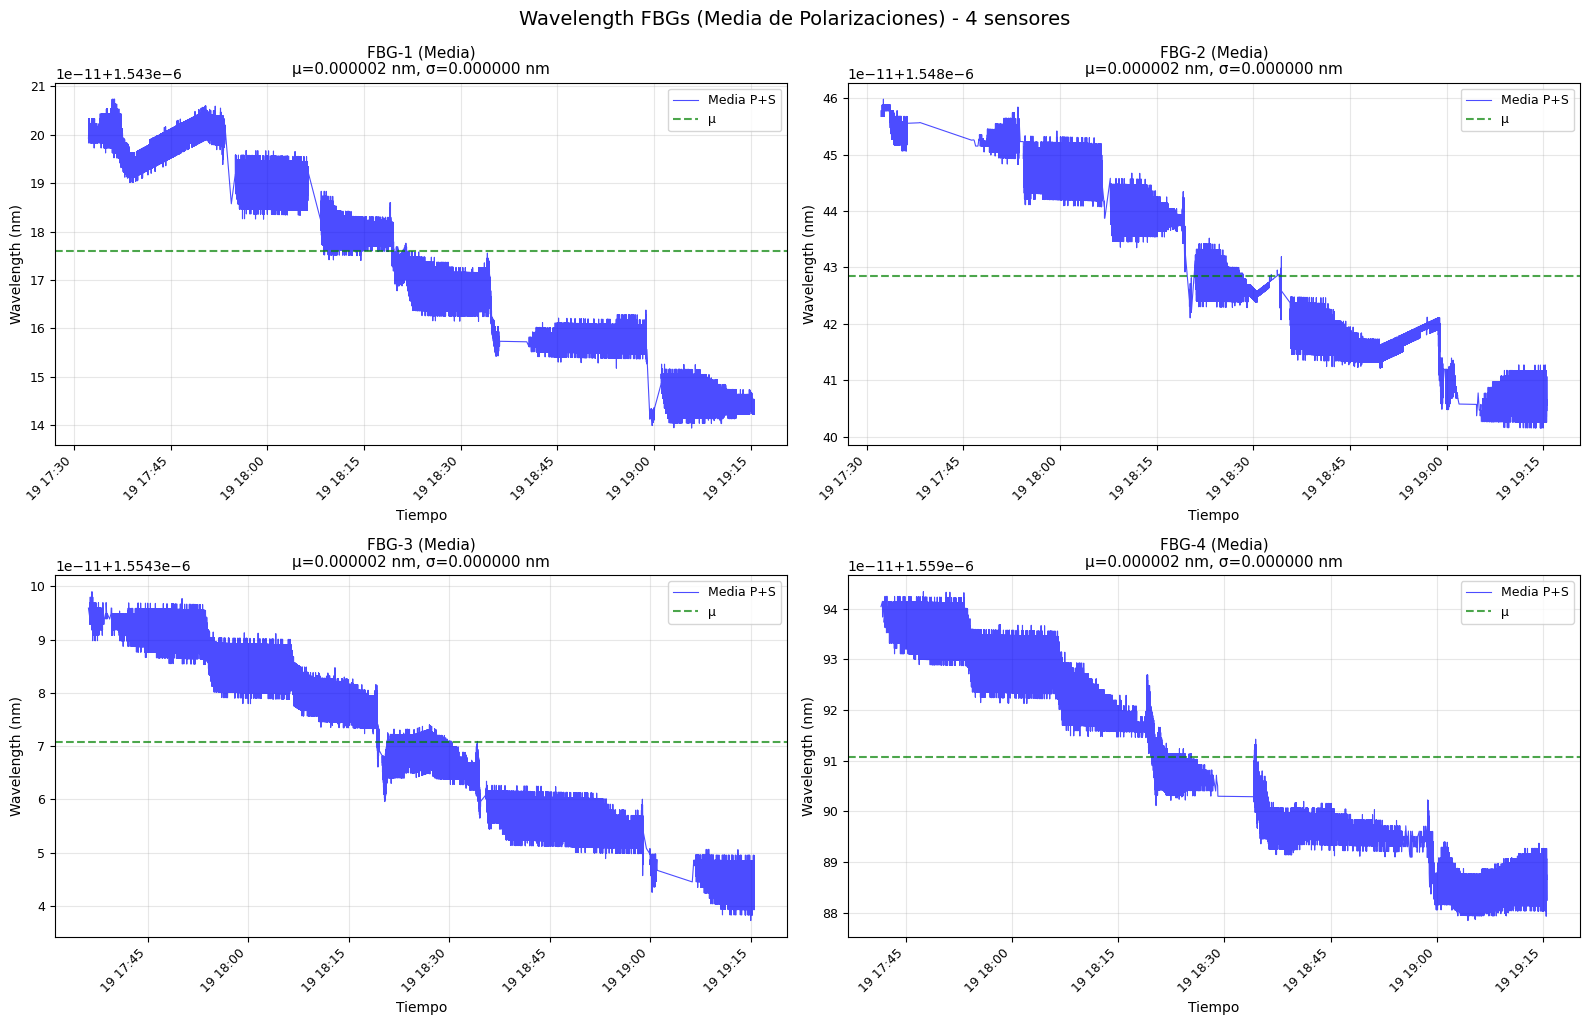

💡 Ejecuta primero la celda 6.3 (definición de plateaus) para ver las líneas verticales


In [10]:
# Ajustar layout para 4 sensores
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    
    # Añadir líneas verticales de plateaus (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            axes[idx].axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.2, alpha=0.5)
            axes[idx].axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.2, alpha=0.5)
    
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.6f} nm, σ={data['std']:.6f} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores', fontsize=14, y=1.02)
plt.show()

if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"💡 Ejecuta primero la celda 6.3 (definición de plateaus) para ver las líneas verticales")

## 6️⃣ Correlación Temperatura/Presión - Wavelength

### 6.1 Seleccionar RTD de Referencia

In [11]:
# Usar RTD-6 (cápsula fibra) como referencia
rtd_ref_idx = 6
rtd_ref_name = "RTD-6 (Cápsula)"

temp_ref = temp_filtered[:, rtd_ref_idx]
mask_temp_valid = temp_ref > 0
times_temp_ref = times_temp_filtered[mask_temp_valid]
temp_ref_valid = temp_ref[mask_temp_valid]

# Presión válida en el rango filtrado
press_valid_filtered_mask = press_filtered > 0
times_press_ref = times_press_filtered[press_valid_filtered_mask]
press_ref_valid = press_filtered[press_valid_filtered_mask]

print(f"✅ Referencia temperatura: {rtd_ref_name}")
print(f"   Rango: [{np.min(temp_ref_valid):.2f}, {np.max(temp_ref_valid):.2f}] K")
print(f"\n✅ Presión:")
print(f"   Rango: [{np.min(press_ref_valid):.2f}, {np.max(press_ref_valid):.2f}] bar")

✅ Referencia temperatura: RTD-6 (Cápsula)
   Rango: [77.10, 91.52] K

✅ Presión:
   Rango: [0.01, 3.09] bar


/tmp/vgarciap/ipykernel_411581/1914553500.py:97: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/afs/cern.ch/user/v/vgarciap/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


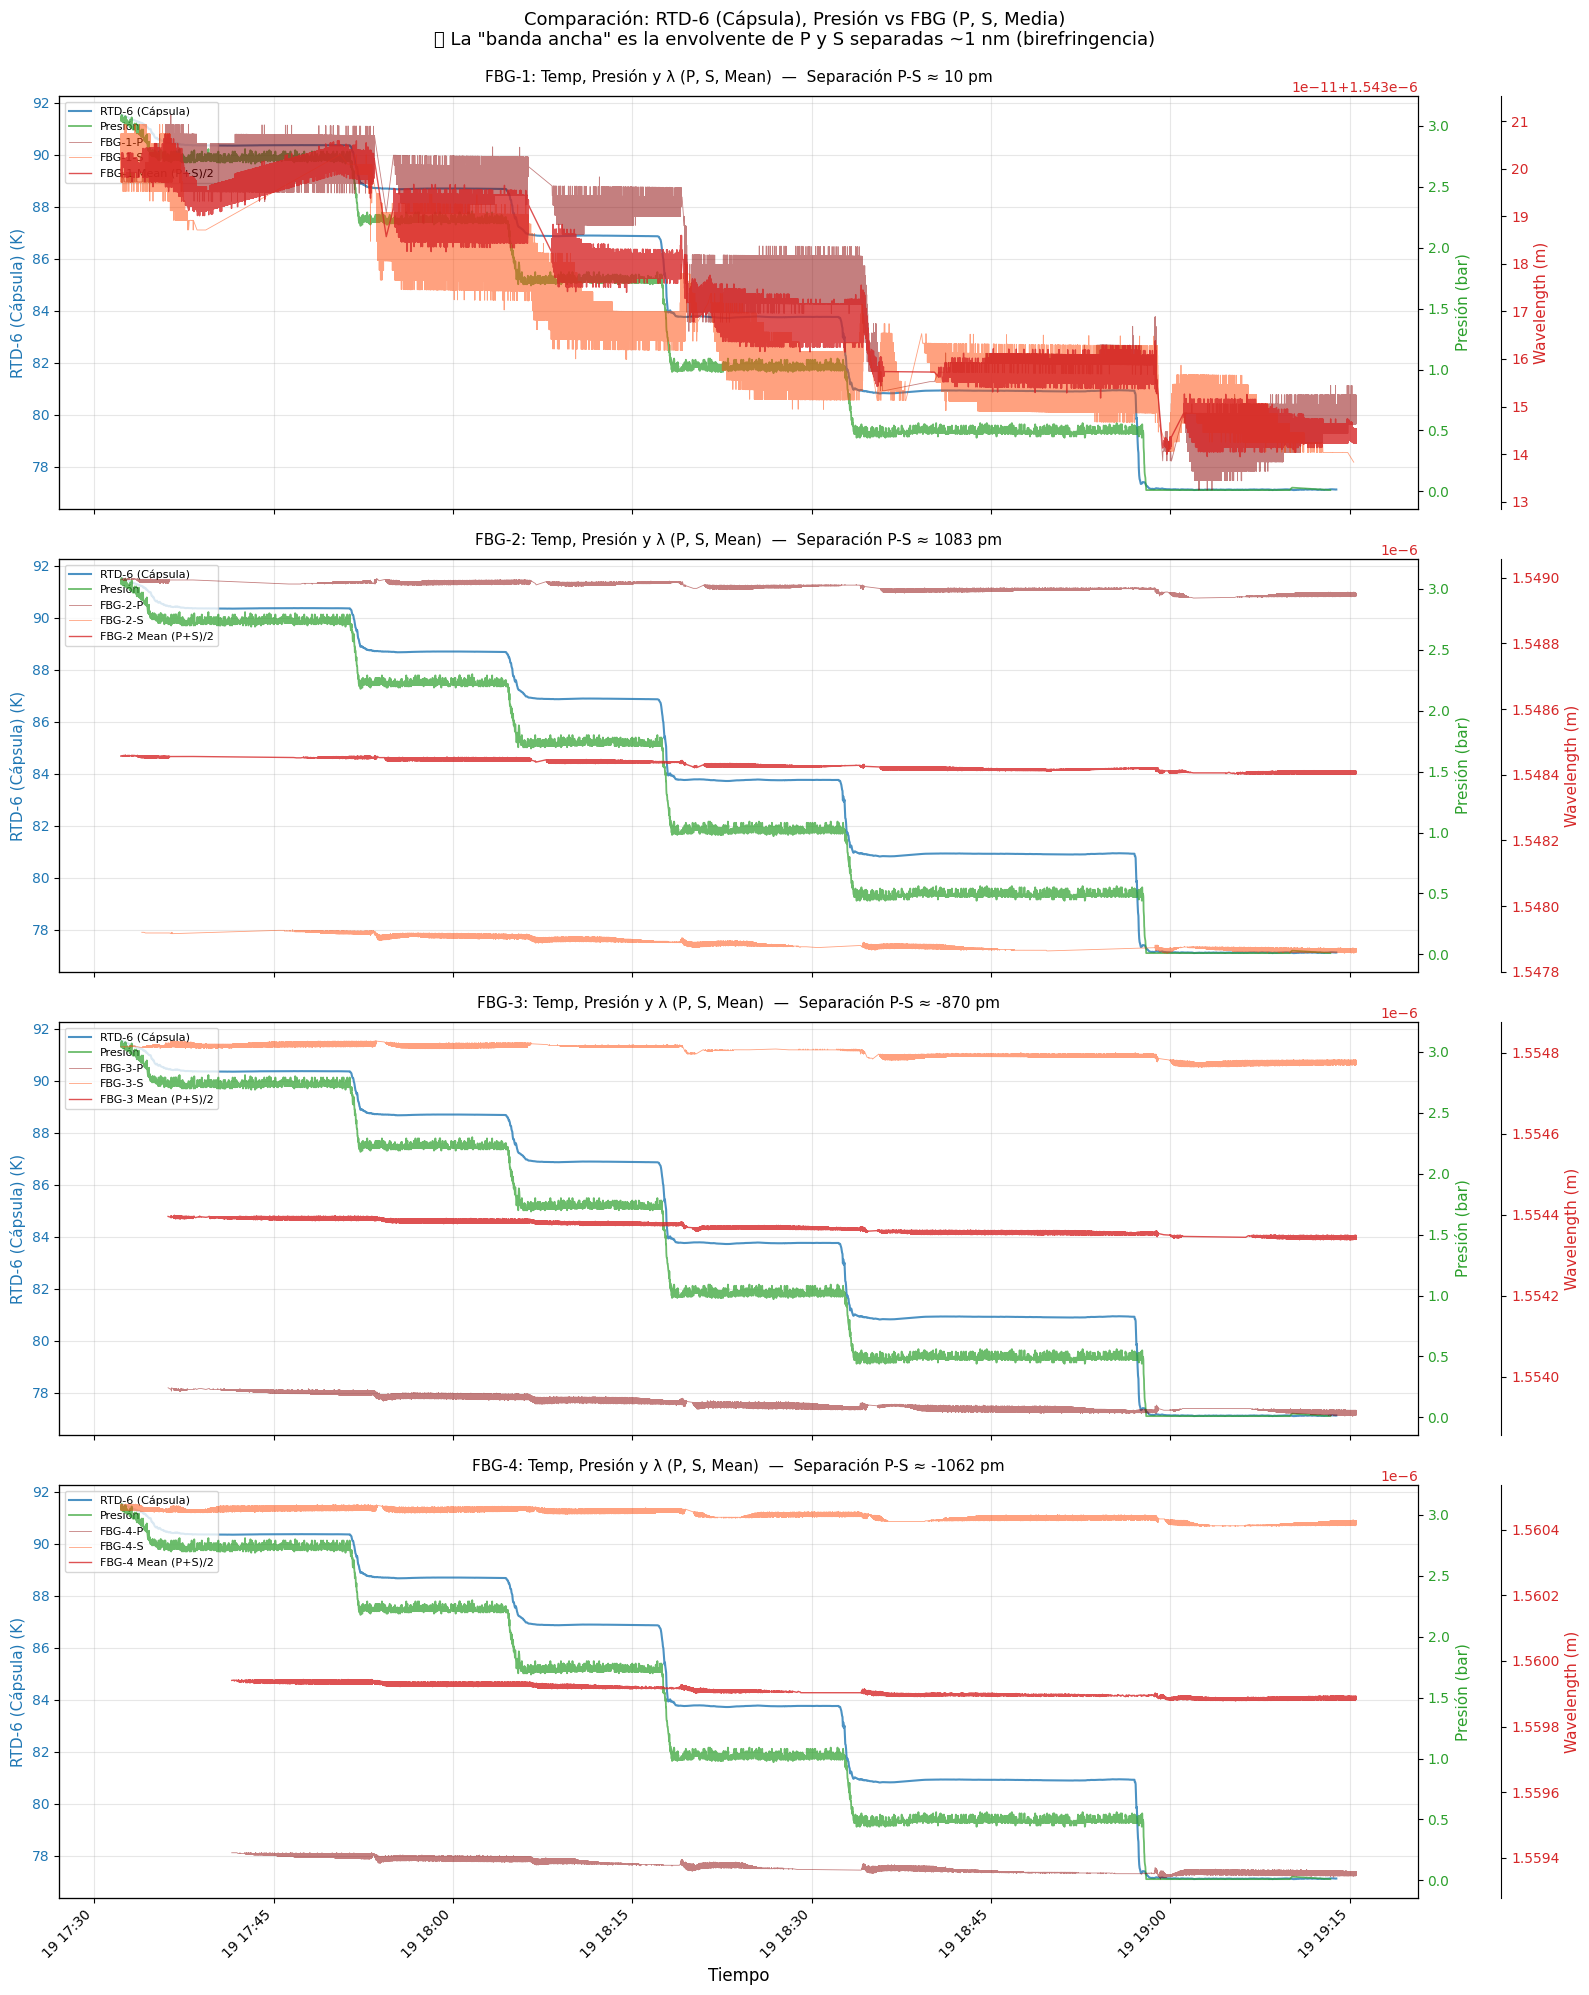

✅ Gráficos superpuestos generados para 4 sensores FBG
   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados


In [12]:
# Superposición de temperatura, presión y wavelength (subplots para cada FBG)
n_sensors_plot = len(fbg_mean_data)
fig, axes = plt.subplots(n_sensors_plot, 1, figsize=(16, 5*n_sensors_plot), sharex=True)

# Asegurar que axes sea un array
if n_sensors_plot == 1:
    axes = [axes]

color_temp = 'tab:blue'
color_press = 'tab:green'
color_wav = 'tab:red'

for idx, sensor_num in enumerate([1, 2, 3, 4][:n_sensors_plot]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    fbg_data_plot = fbg_mean_data[fbg_label]
    
    ax1 = axes[idx]
    
    # Eje izquierdo: Temperatura
    ax1.set_ylabel(f'{rtd_ref_name} (K)', fontsize=11, color=color_temp)
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.8, label=rtd_ref_name)
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.3, axis='both')
    
    # Marcar plateaus con líneas verticales (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            ax1.axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax1.axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Eje derecho 1: Presión
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 0))
    ax2.set_ylabel('Presión (bar)', fontsize=11, color=color_press)
    ax2.plot(times_press_ref, press_ref_valid, color=color_press, linewidth=1.3, alpha=0.7, label='Presión')
    ax2.tick_params(axis='y', labelcolor=color_press)
    
    # Eje derecho 2: Wavelength (P, S, y media)
    # Extraer datos de P y S para mostrar la separación
    key_p = f"FBG-{sensor_num}-P"
    key_s = f"FBG-{sensor_num}-S"
    data_p = fbg_filtered_data[key_p]
    data_s = fbg_filtered_data[key_s]
    
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.set_ylabel('Wavelength (m)', fontsize=11, color=color_wav)
    
    # Plot P, S, y Mean con colores diferenciados
    ax3.plot(data_p["timestamps"], data_p["wavelength"], 
             color='darkred', linewidth=0.6, alpha=0.5, label=f'FBG-{sensor_num}-P')
    ax3.plot(data_s["timestamps"], data_s["wavelength"], 
             color='orangered', linewidth=0.6, alpha=0.5, label=f'FBG-{sensor_num}-S')
    ax3.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=1.0, alpha=0.8, 
             label=f'FBG-{sensor_num} Mean (P+S)/2')
    
    # Calcular y mostrar separación P-S típica
    tp = data_p["timestamps"]
    ts = data_s["timestamps"]
    tp_sec = np.array([t.timestamp() for t in tp])
    ts_sec = np.array([t.timestamp() for t in ts])
    ws_interp = np.interp(tp_sec, ts_sec, data_s["wavelength"])
    sep_pm = np.median((data_p["wavelength"] - ws_interp)) * 1e12  # m → pm
    
    ax3.tick_params(axis='y', labelcolor=color_wav)
    
    # Leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    
    # Añadir leyenda para plateaus si existen
    if 'plateau_data' in globals() and len(plateau_data) > 0 and idx == 0:
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.5),
                       Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5)]
        ax1.legend(lines1 + lines2 + lines3 + custom_lines, 
                  labels1 + labels2 + labels3 + ['Inicio plateau', 'Fin plateau'], 
                  loc='upper left', fontsize=8)
    else:
        ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left', fontsize=8)
    
    # Título del subplot con separación P-S
    ax1.set_title(f'FBG-{sensor_num}: Temp, Presión y λ (P, S, Mean)  —  Separación P-S ≈ {sep_pm:.0f} pm', 
                  fontsize=11, pad=10)

# Solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=12)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Comparación: {rtd_ref_name}, Presión vs FBG (P, S, Media)\n'
             f'💡 La "banda ancha" es la envolvente de P y S separadas ~1 nm (birefringencia)', 
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"✅ Gráficos superpuestos generados para {n_sensors_plot} sensores FBG")
if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"   🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados")

### 6.2 Visualización de Perfiles (para definir plateaus)

Superposición de temperatura, presión y wavelength para identificar visualmente los plateaus.

### 6.3 Definición Manual de Plateaus

**✏️ Define aquí los intervalos temporales de plateau identificados en los gráficos anteriores**

Plateaus basados en niveles de presión (11/02/2026):
- **15:53h**: Primer plateau a 2.75 bar en equilibrio
- **16:09h**: Bajo a 2.4 bar
- **16:23h**: Bajo a 2.03 bar
- **16:36h**: Bajo a 1.5 bar (se estabiliza a 1.52 bar)
- **16:54h**: Bajo a 1 bar
- **17:10h**: Plateau adicional

Los intervalos definidos son conservadores (3-4 min después del cambio, terminan antes del siguiente) para asegurar estabilidad.

In [13]:
# ============================================================================
# DEFINICIÓN MANUAL DE PLATEAUS (basados en niveles de presión)
# ============================================================================
# Fecha del experimento
fecha = datetime.date(2026, 2, 19)

# Formato: [("Nombre", "HH:MM", "HH:MM"), ...]
# ⚠️ Los datos cubren el rango 17:31 - 19:14 (con TIME_SHIFT aplicado)
# Ajusta los tiempos de los plateaus según lo que veas en el gráfico de presión

manual_plateaus = [
    ("Plateau 1 (2.75 bar)", "17:35", "17:45"),
    ("Plateau 2 (2.4 bar)",  "17:50", "18:00"),
    ("Plateau 3 (2.0 bar)",  "18:05", "18:15"),
    ("Plateau 4 (1.5 bar)",  "18:20", "18:30"),
    ("Plateau 5 (1.0 bar)",  "18:35", "18:45"),
    ("Plateau 6",            "18:50", "19:00"),
]

# Activar plateaus manuales
use_manual_plateaus = True

# Procesar plateaus
plateau_data = []

if use_manual_plateaus and len(manual_plateaus) > 0:
    print("✅ Usando plateaus manuales:")
    print("="*80)
    
    for name, t0_str, tfin_str in manual_plateaus:
        t0 = datetime.datetime.combine(fecha, datetime.datetime.strptime(t0_str, "%H:%M").time())
        tfin = datetime.datetime.combine(fecha, datetime.datetime.strptime(tfin_str, "%H:%M").time())
        
        # Calcular media y std de temperatura en el plateau
        mask_temp_plateau = (times_temp_ref >= t0) & (times_temp_ref <= tfin)
        temp_plateau = temp_ref_valid[mask_temp_plateau]
        
        # Calcular media y std de presión en el plateau
        mask_press_plateau = (times_press_ref >= t0) & (times_press_ref <= tfin)
        press_plateau = press_ref_valid[mask_press_plateau]
        
        if len(temp_plateau) > 0:
            temp_mean = np.mean(temp_plateau)
            temp_std = np.std(temp_plateau)
            
            # Calcular media y std de presión (datos siempre disponibles en esta adquisición)
            if len(press_plateau) > 0:
                press_mean = np.mean(press_plateau)
                press_std = np.std(press_plateau)
            else:
                # Si no hay datos de presión en este rango, usar NaN
                press_mean = np.nan
                press_std = np.nan
            
            plateau_info = {
                "name": name,
                "t0": t0,
                "tfin": tfin,
                "temp_mean": temp_mean,
                "temp_std": temp_std,
                "press_mean": press_mean,
                "press_std": press_std,
                "n_temp_points": len(temp_plateau),
                "n_press_points": len(press_plateau)
            }
            
            plateau_data.append(plateau_info)
            
            print(f"{name}: {t0_str} - {tfin_str}")
            print(f"  Temperatura: μ={temp_mean:.3f}K, σ={temp_std:.4f}K, n={len(temp_plateau)}")
            print(f"  Presión:     μ={press_mean:.3f}bar, σ={press_std:.4f}bar, n={len(press_plateau)}")
        else:
            print(f"⚠️ {name}: No hay datos de temperatura en este rango")
    
    print("="*80)
    print(f"\n✅ {len(plateau_data)} plateaus definidos")
else:
    print("ℹ️ Plateaus desactivados")

✅ Usando plateaus manuales:
Plateau 1 (2.75 bar): 17:35 - 17:45
  Temperatura: μ=90.384K, σ=0.0706K, n=296
  Presión:     μ=2.736bar, σ=0.0241bar, n=597
Plateau 2 (2.4 bar): 17:50 - 18:00
  Temperatura: μ=89.021K, σ=0.6219K, n=300
  Presión:     μ=2.318bar, σ=0.1886bar, n=596
Plateau 3 (2.0 bar): 18:05 - 18:15
  Temperatura: μ=86.929K, σ=0.1609K, n=300
  Presión:     μ=1.740bar, σ=0.0364bar, n=597
Plateau 4 (1.5 bar): 18:20 - 18:30
  Temperatura: μ=83.751K, σ=0.0162K, n=300
  Presión:     μ=1.019bar, σ=0.0243bar, n=594
Plateau 5 (1.0 bar): 18:35 - 18:45
  Temperatura: μ=80.891K, σ=0.0404K, n=300
  Presión:     μ=0.489bar, σ=0.0227bar, n=595
Plateau 6: 18:50 - 19:00
  Temperatura: μ=79.891K, σ=1.6292K, n=301
  Presión:     μ=0.480bar, σ=0.0709bar, n=478

✅ 6 plateaus definidos


### 6.4 Calcular Sensibilidad por Plateaus

Calcula la media y std de wavelength en cada plateau para cada sensor FBG.

In [14]:
# Calcular media y std de wavelength por plateau para cada sensor
plateau_sensitivity_data = {}

for fbg_label, fbg_data in fbg_mean_data.items():
    sensor_num = fbg_data["sensor_num"]
    fbg_times = fbg_data["timestamps"]
    fbg_wav = fbg_data["wavelength"]
    
    plateau_wav_stats = []
    
    for plateau in plateau_data:
        # Máscara para datos de wavelength en este plateau
        mask_wav_plateau = (fbg_times >= plateau["t0"]) & (fbg_times <= plateau["tfin"])
        wav_plateau = fbg_wav[mask_wav_plateau]
        
        if len(wav_plateau) > 0:
            wav_mean = np.mean(wav_plateau)
            wav_std = np.std(wav_plateau)
            
            plateau_wav_stats.append({
                "name": plateau["name"],
                "temp_mean": plateau["temp_mean"],
                "temp_std": plateau["temp_std"],
                "press_mean": plateau["press_mean"],
                "press_std": plateau["press_std"],
                "wav_mean": wav_mean,
                "wav_std": wav_std,
                "n_wav_points": len(wav_plateau)
            })
    
    plateau_sensitivity_data[fbg_label] = plateau_wav_stats

print("✅ Estadísticas de wavelength calculadas por plateau")
print("\nResumen por sensor:")
print("="*80)
for fbg_label in fbg_mean_data.keys():
    sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
    n_plateaus = len(plateau_sensitivity_data[fbg_label])
    print(f"FBG-{sensor_num}: {n_plateaus} plateaus procesados")

✅ Estadísticas de wavelength calculadas por plateau

Resumen por sensor:
FBG-1: 6 plateaus procesados
FBG-2: 6 plateaus procesados
FBG-3: 6 plateaus procesados
FBG-4: 6 plateaus procesados


### 6.5 Visualizar Sensibilidad (Temp vs Wavelength con barras de error)

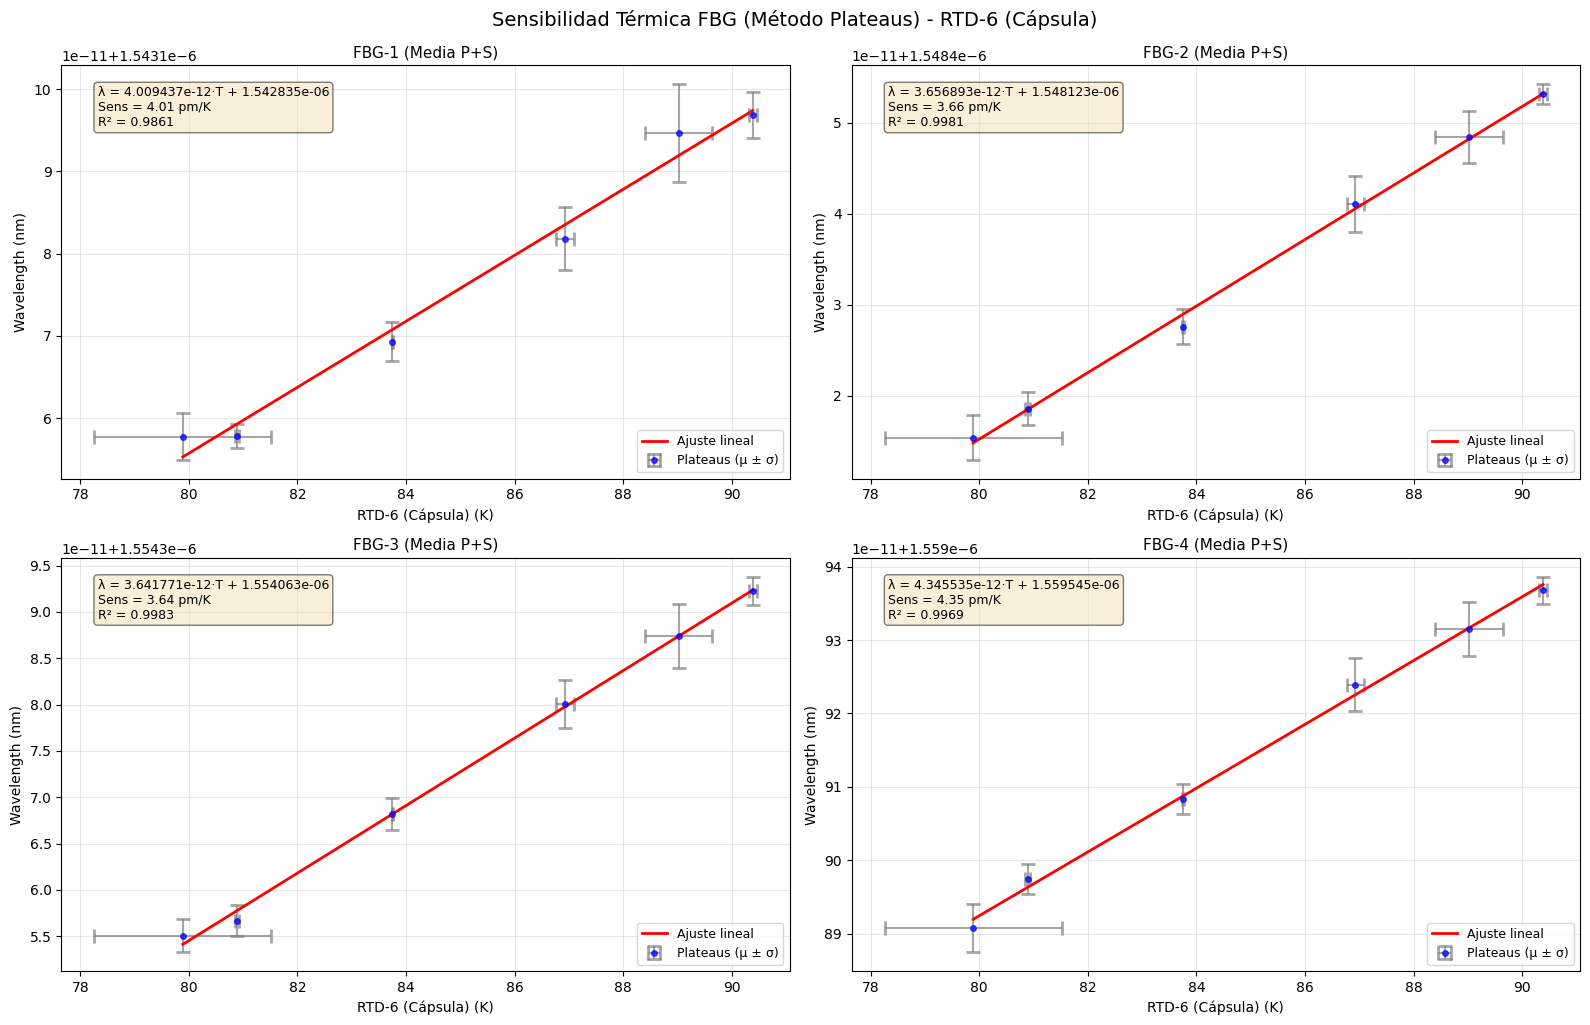


SENSIBILIDADES TÉRMICAS (Método Plateaus)
Sensor          Sensibilidad       R²           N Plateaus   p-value
FBG-1              4.01 pm/K     0.986131     6            7.25e-05
FBG-2              3.66 pm/K     0.998058     6            1.42e-06
FBG-3              3.64 pm/K     0.998304     6            1.08e-06
FBG-4              4.35 pm/K     0.996902     6            3.60e-06


In [15]:
# Ajustar layout para 3 sensores
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Diccionario para guardar sensibilidades
plateau_sensitivities = {}

for idx, (fbg_label, fbg_data) in enumerate(fbg_mean_data.items()):
    sensor_num = fbg_data["sensor_num"]
    plateau_stats = plateau_sensitivity_data[fbg_label]
    
    if len(plateau_stats) == 0:
        print(f"⚠️ FBG-{sensor_num}: No hay plateaus con datos")
        continue
    
    # Extraer datos para ajuste lineal
    temp_means = np.array([p["temp_mean"] for p in plateau_stats])
    temp_stds = np.array([p["temp_std"] for p in plateau_stats])
    wav_means = np.array([p["wav_mean"] for p in plateau_stats])
    wav_stds = np.array([p["wav_std"] for p in plateau_stats])
    
    # Ajuste lineal
    slope, intercept, r_value, p_value, std_err = stats.linregress(temp_means, wav_means)
    
    # Guardar sensibilidad
    plateau_sensitivities[fbg_label] = {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_value**2,
        "p_value": p_value,
        "std_err": std_err,
        "sensitivity_pm_K": slope * 1e12,  # m/K → pm/K
        "n_plateaus": len(plateau_stats)
    }
    
    # Plot
    ax = axes[idx]
    
    # Puntos con barras de error (markersize más pequeño para ver mejor las barras)
    ax.errorbar(temp_means, wav_means, 
                xerr=temp_stds, yerr=wav_stds,
                fmt='o', markersize=4, capsize=5, capthick=2,
                color='blue', ecolor='gray', alpha=0.7,
                label='Plateaus (μ ± σ)')
    
    # Línea de ajuste
    temp_range = np.array([temp_means.min(), temp_means.max()])
    wav_fit = slope * temp_range + intercept
    ax.plot(temp_range, wav_fit, 'r-', linewidth=2, label='Ajuste lineal')
    
    # Añadir ecuación de la recta en el plot
    sensitivity_pm = slope * 1e12  # m/K → pm/K
    equation_text = f'λ = {slope:.6e}·T + {intercept:.6e}\n'
    equation_text += f'Sens = {sensitivity_pm:.2f} pm/K\n'
    equation_text += f'R² = {r_value**2:.4f}'
    
    # Posicionar el texto en la esquina superior izquierda
    ax.text(0.05, 0.95, equation_text, 
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Configuración del plot
    ax.set_title(f"FBG-{sensor_num} (Media P+S)", fontsize=11)
    ax.set_xlabel(f'{rtd_ref_name} (K)', fontsize=10)
    ax.set_ylabel('Wavelength (nm)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.suptitle(f'Sensibilidad Térmica FBG (Método Plateaus) - {rtd_ref_name}', 
             fontsize=14, y=1.02)
plt.show()

# Resumen de sensibilidades
print("\n" + "="*80)
print("SENSIBILIDADES TÉRMICAS (Método Plateaus)")
print("="*80)
print(f"{'Sensor':<15} {'Sensibilidad':<18} {'R²':<12} {'N Plateaus':<12} {'p-value'}")
print("="*80)

for fbg_label in fbg_mean_data.keys():
    if fbg_label in plateau_sensitivities:
        sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
        sens_data = plateau_sensitivities[fbg_label]
        
        print(f"FBG-{sensor_num}        {sens_data['sensitivity_pm_K']:>10.2f} pm/K     "
              f"{sens_data['r_squared']:<12.6f} {sens_data['n_plateaus']:<12d} {sens_data['p_value']:<.2e}")

print("="*80)

### 6.6 Visualizar Sensibilidad (Presión vs Wavelength con barras de error)

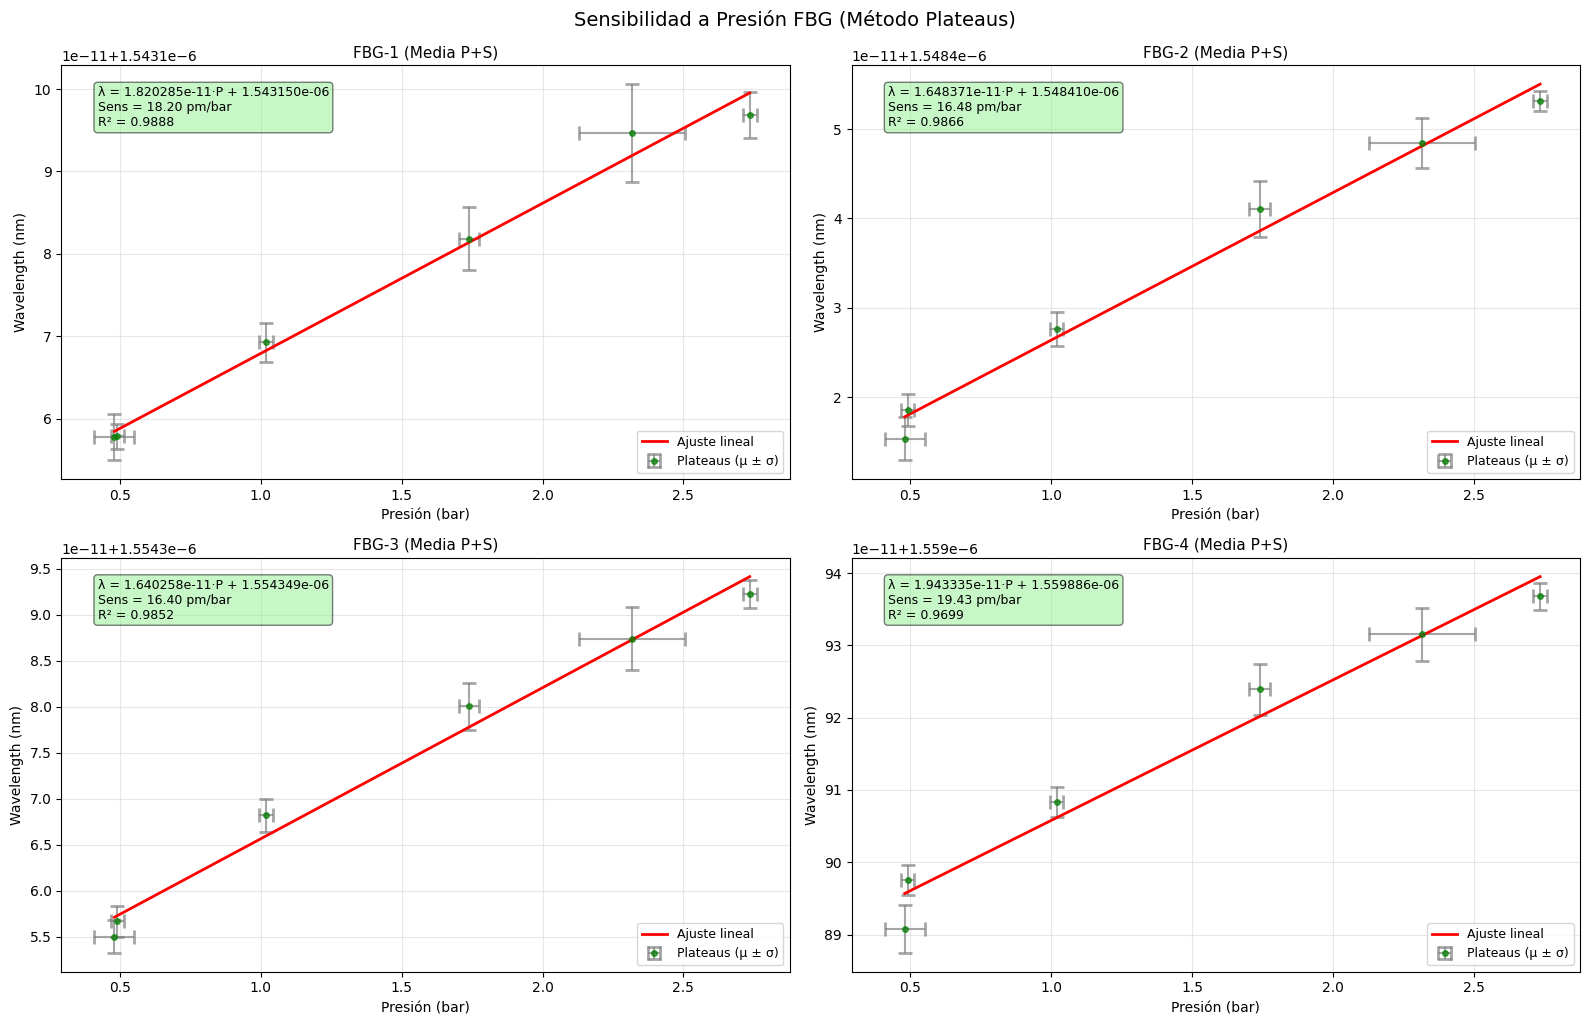


SENSIBILIDADES A PRESIÓN (Método Plateaus)
Sensor          Sensibilidad       R²           N Plateaus   p-value
FBG-1             18.20 pm/bar   0.988849     6            4.68e-05
FBG-2             16.48 pm/bar   0.986562     6            6.80e-05
FBG-3             16.40 pm/bar   0.985246     6            8.20e-05
FBG-4             19.43 pm/bar   0.969939     6            3.42e-04


In [16]:
# Ajustar layout para 3 sensores - Sensibilidad a presión
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Diccionario para guardar sensibilidades a presión
plateau_press_sensitivities = {}

for idx, (fbg_label, fbg_data) in enumerate(fbg_mean_data.items()):
    sensor_num = fbg_data["sensor_num"]
    plateau_stats = plateau_sensitivity_data[fbg_label]
    
    if len(plateau_stats) == 0:
        print(f"⚠️ FBG-{sensor_num}: No hay plateaus con datos")
        continue
    
    # Extraer datos para ajuste lineal (presión vs wavelength)
    press_means = np.array([p["press_mean"] for p in plateau_stats])
    press_stds = np.array([p["press_std"] for p in plateau_stats])
    wav_means = np.array([p["wav_mean"] for p in plateau_stats])
    wav_stds = np.array([p["wav_std"] for p in plateau_stats])
    
    # Ajuste lineal
    slope_p, intercept_p, r_value_p, p_value_p, std_err_p = stats.linregress(press_means, wav_means)
    
    # Guardar sensibilidad a presión
    plateau_press_sensitivities[fbg_label] = {
        "slope": slope_p,
        "intercept": intercept_p,
        "r_squared": r_value_p**2,
        "p_value": p_value_p,
        "std_err": std_err_p,
        "sensitivity_pm_bar": slope_p * 1e12,  # m/bar -> pm/bar
        "n_plateaus": len(plateau_stats)
    }
    
    # Plot
    ax = axes[idx]
    
    # Puntos con barras de error
    ax.errorbar(press_means, wav_means, 
                xerr=press_stds, yerr=wav_stds,
                fmt='o', markersize=4, capsize=5, capthick=2,
                color='green', ecolor='gray', alpha=0.7,
                label='Plateaus (μ ± σ)')
    
    # Línea de ajuste
    press_range = np.array([press_means.min(), press_means.max()])
    wav_fit_p = slope_p * press_range + intercept_p
    ax.plot(press_range, wav_fit_p, 'r-', linewidth=2, label='Ajuste lineal')
    
    # Añadir ecuación de la recta en el plot
    sensitivity_pm_bar = slope_p * 1e12
    equation_text = f'λ = {slope_p:.6e}·P + {intercept_p:.6e}\n'  # meters, scientific notation
    equation_text += f'Sens = {sensitivity_pm_bar:.2f} pm/bar\n'
    equation_text += f'R² = {r_value_p**2:.4f}'
    
    # Posicionar el texto en la esquina superior izquierda
    ax.text(0.05, 0.95, equation_text, 
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    # Configuración del plot
    ax.set_title(f"FBG-{sensor_num} (Media P+S)", fontsize=11)
    ax.set_xlabel('Presión (bar)', fontsize=10)
    ax.set_ylabel('Wavelength (nm)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.suptitle(f'Sensibilidad a Presión FBG (Método Plateaus)', 
             fontsize=14, y=1.02)
plt.show()

# Resumen de sensibilidades a presión
print("\n" + "="*80)
print("SENSIBILIDADES A PRESIÓN (Método Plateaus)")
print("="*80)
print(f"{'Sensor':<15} {'Sensibilidad':<18} {'R²':<12} {'N Plateaus':<12} {'p-value'}")
print("="*80)

for fbg_label in fbg_mean_data.keys():
    if fbg_label in plateau_press_sensitivities:
        sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
        sens_data = plateau_press_sensitivities[fbg_label]
        
        print(f"FBG-{sensor_num}        {sens_data['sensitivity_pm_bar']:>10.2f} pm/bar   "
              f"{sens_data['r_squared']:<12.6f} {sens_data['n_plateaus']:<12d} {sens_data['p_value']:<.2e}")

print("="*80)

## 7️⃣ Evolución Temporal Completa (Todo el rango con TIME_SHIFT aplicado)

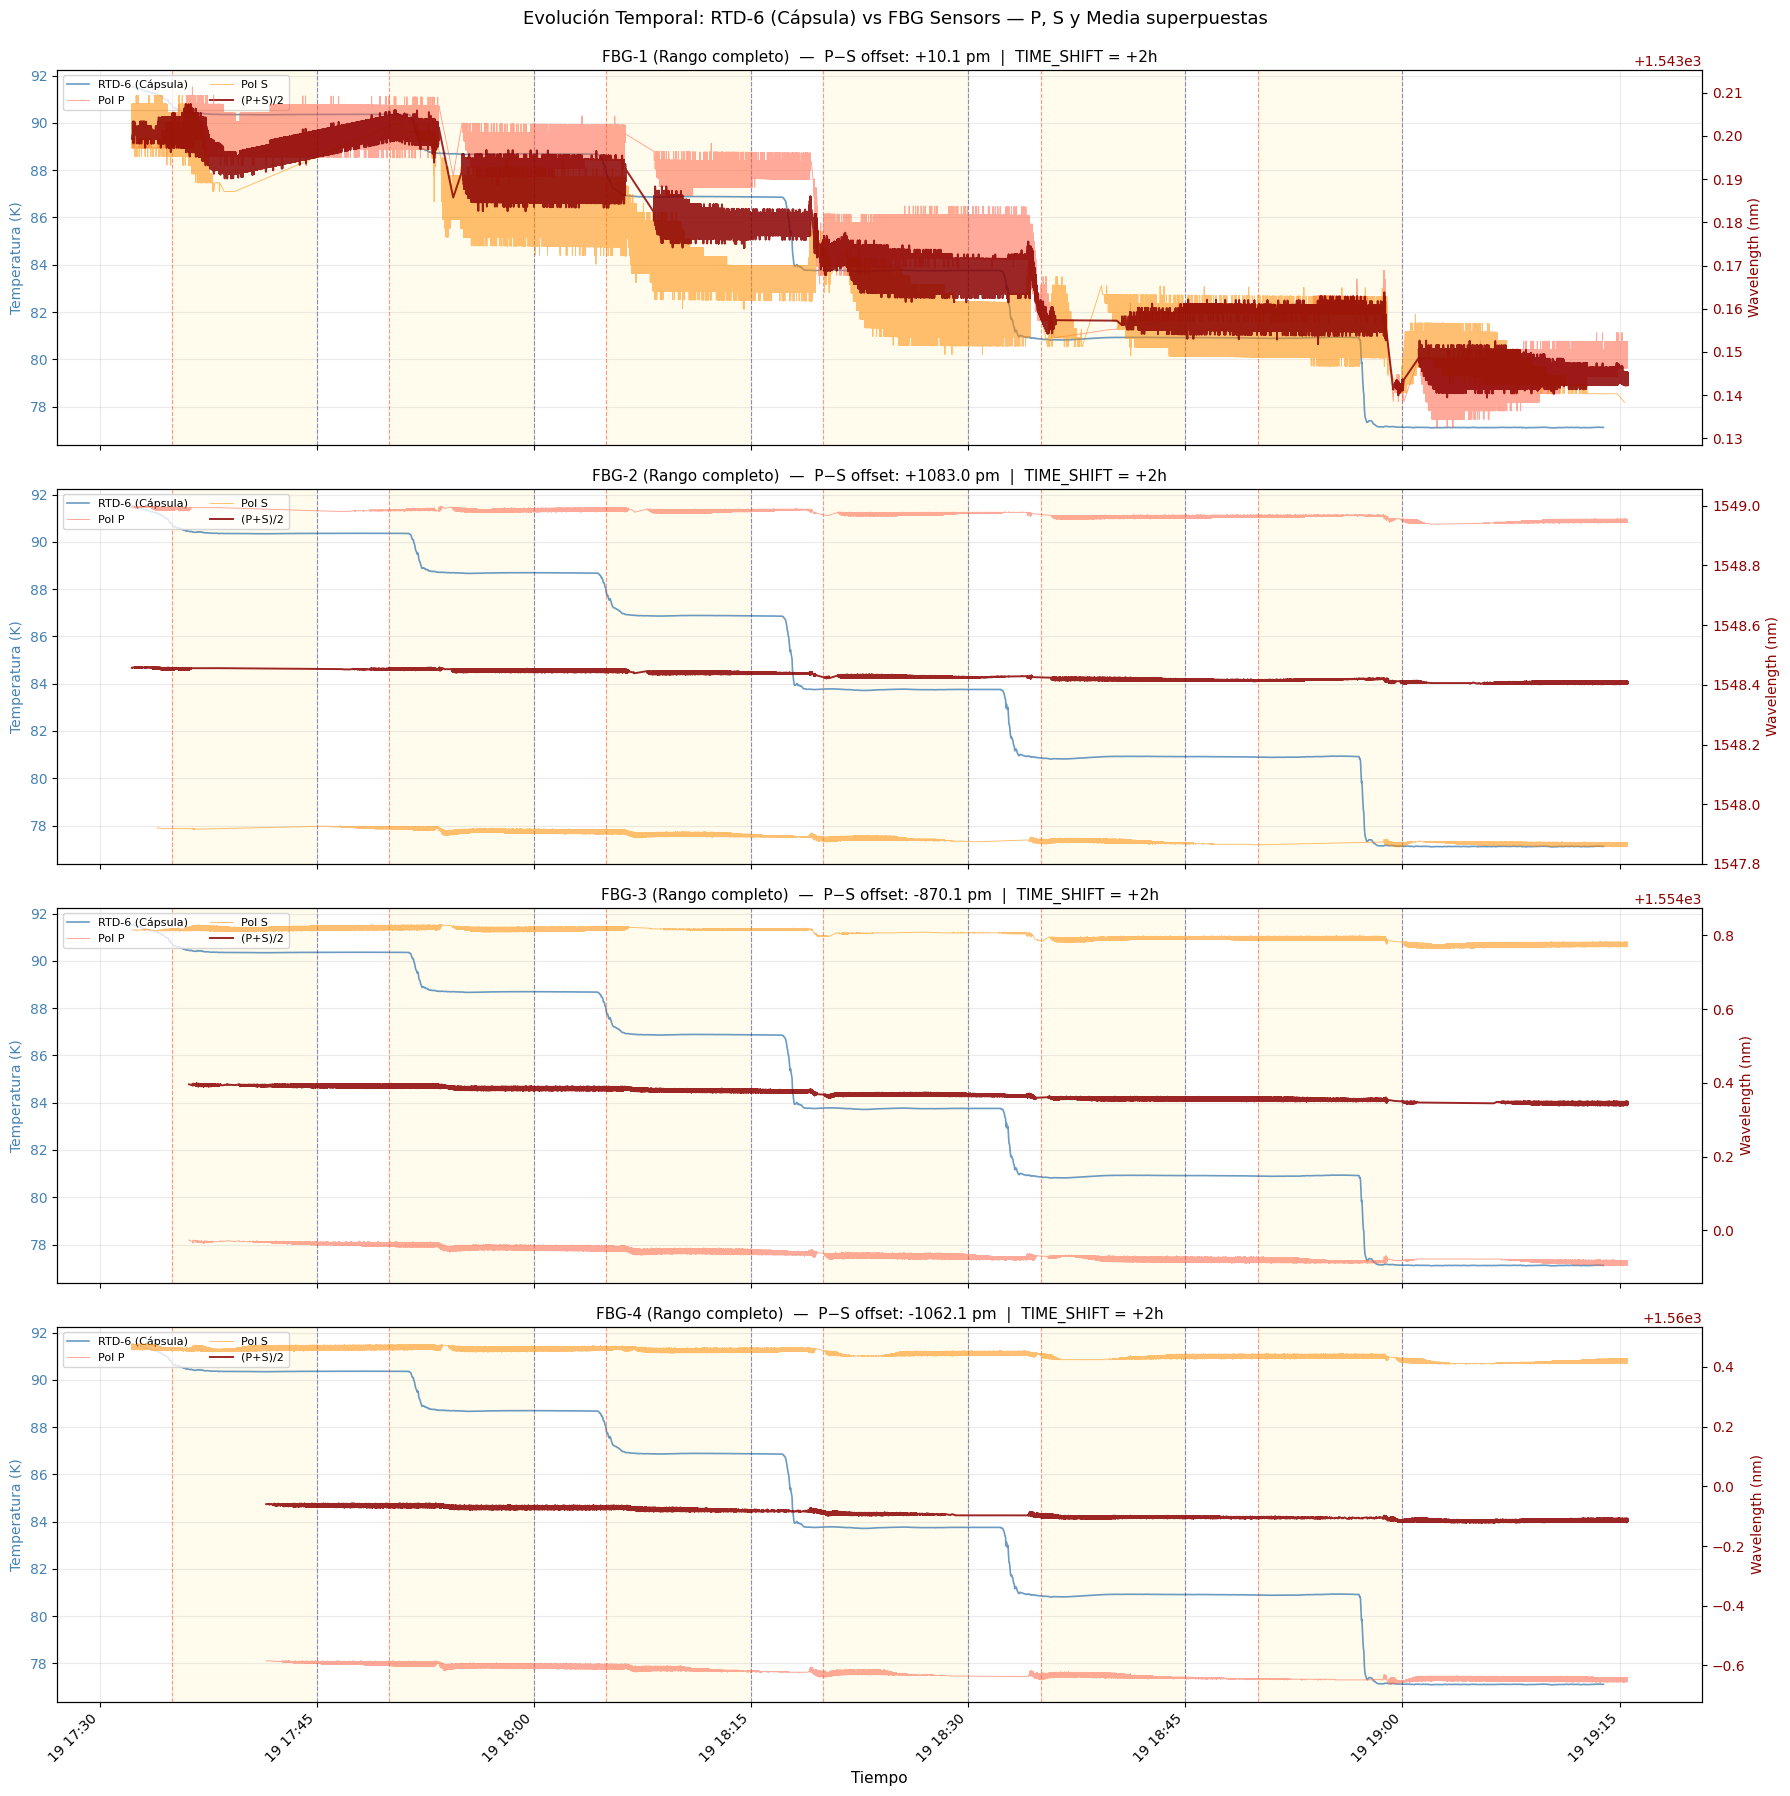


════════════════════════════════════════════════════════════
  Separación mediana λ_P − λ_S  (= birefringencia óptica)
────────────────────────────────────────────────────────────
  FBG-1:    +10.1 pm  (+0.0101 nm)
  FBG-2:  +1083.0 pm  (+1.0830 nm)
  FBG-3:   -870.1 pm  (-0.8701 nm)
  FBG-4:  -1062.1 pm  (-1.0621 nm)
════════════════════════════════════════════════════════════

💡 Un offset P−S grande pero CONSTANTE no afecta la sensibilidad
   calculada con (P+S)/2 — solo el DRIFT del offset importa.
   FBG-1 muestra drift (ver D1): ese drift se traduce en 'plateau ancho'.


In [17]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
use_filtered_range_plot = False

times_peak = time_wavelength_shifted

if use_filtered_range_plot:
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(17, 30))
    t_plot_fin    = datetime.datetime.combine(fecha, datetime.time(19, 15))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    t_plot_inicio = times_peak[0]
    t_plot_fin    = times_peak[-1]
    range_label = "(Rango completo)"

# Filtrar temperatura
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

def robust_mask(arr):
    valid = arr > 0
    if np.sum(valid) == 0:
        return valid
    med = np.median(arr[valid])
    mad = np.median(np.abs(arr[valid] - med))
    if mad == 0:
        mad = np.std(arr[valid]) * 0.6745
    return valid & (np.abs(arr - med) <= 5 * mad)

n_sensors_temporal = len(fbg_mean_data)
fig, axes = plt.subplots(n_sensors_temporal, 1, figsize=(18, 4.5 * n_sensors_temporal), sharex=True)
if n_sensors_temporal == 1:
    axes = [axes]

for idx, sensor_num in enumerate(range(1, num_sensores + 1)):
    if idx >= len(axes):
        break
    fbg_label = f"FBG-{sensor_num}-Mean"
    if fbg_label not in fbg_mean_data:
        continue

    sensor_idx = sensor_num - 1
    wav_p_full = wav_raw[:, 0, sensor_idx]
    wav_s_full = wav_raw[:, 1, sensor_idx]

    mask_p = robust_mask(wav_p_full) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = robust_mask(wav_s_full) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)

    tp = times_peak[mask_p]
    ts = times_peak[mask_s]
    wp = wav_p_full[mask_p] * 1e9   # m → nm
    ws = wav_s_full[mask_s] * 1e9

    # Mean: interpolate S onto P timestamps
    tp_sec = np.array([t.timestamp() for t in tp])
    ts_sec = np.array([t.timestamp() for t in ts])
    ws_interp = np.interp(tp_sec, ts_sec, ws)
    wav_mean_plot = (wp + ws_interp) / 2.0

    ax = axes[idx]

    # Temperatura (eje izquierdo)
    ax.plot(times_temp_plot, temp_plot, color='steelblue', lw=1.2, alpha=0.8, label=rtd_ref_name)
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax.grid(True, alpha=0.25)

    # Marcar plateaus
    for pl in plateau_data:
        ax.axvspan(pl["t0"], pl["tfin"], alpha=0.07, color='gold')
        ax.axvline(pl["t0"],   color='red',  ls='--', lw=0.8, alpha=0.4)
        ax.axvline(pl["tfin"], color='navy', ls='--', lw=0.8, alpha=0.4)

    # Wavelength P, S, Mean (eje derecho)
    ax2 = ax.twinx()

    # Compute P-S separation for title annotation
    ps_sep_pm = np.median(wp - ws_interp) * 1e3   # nm → pm

    ax2.plot(tp, wp,           color='tomato',   lw=0.7, alpha=0.55, label='Pol P')
    ax2.plot(ts, ws,           color='darkorange', lw=0.7, alpha=0.55, label='Pol S')
    ax2.plot(tp, wav_mean_plot, color='darkred',   lw=1.4, alpha=0.85, label='(P+S)/2')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='darkred')
    ax2.tick_params(axis='y', labelcolor='darkred')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8, ncol=2)

    ax.set_title(
        f'FBG-{sensor_num} {range_label}  —  '
        f'P−S offset: {ps_sep_pm:+.1f} pm  |  '
        f'TIME_SHIFT = +{TIME_SHIFT.total_seconds()/3600:.0f}h',
        fontsize=11)

axes[-1].set_xlabel('Tiempo', fontsize=11)
for lbl in axes[-1].get_xticklabels():
    lbl.set_rotation(45); lbl.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors — P, S y Media superpuestas',
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

# ── Resumen de separación P−S por sensor ─────────────────────────────────────
print(f"\n{'═'*60}")
print(f"  Separación mediana λ_P − λ_S  (= birefringencia óptica)")
print(f"{'─'*60}")
for sensor_num in range(1, num_sensores + 1):
    fbg_label = f"FBG-{sensor_num}-Mean"
    if fbg_label not in fbg_mean_data:
        continue
    sensor_idx = sensor_num - 1
    wp_all = wav_raw[:, 0, sensor_idx]
    ws_all = wav_raw[:, 1, sensor_idx]
    mask_p2 = robust_mask(wp_all)
    mask_s2 = robust_mask(ws_all)
    # align
    t_p2 = times_peak[mask_p2]; t_s2 = times_peak[mask_s2]
    wp2 = wp_all[mask_p2]; ws2 = ws_all[mask_s2]
    tp2_sec = np.array([t.timestamp() for t in t_p2])
    ts2_sec = np.array([t.timestamp() for t in t_s2])
    ws2_i = np.interp(tp2_sec, ts2_sec, ws2)
    sep_pm = np.median((wp2 - ws2_i)) * 1e12   # m → pm
    sep_nm = sep_pm / 1e3
    print(f"  FBG-{sensor_num}: {sep_pm:+8.1f} pm  ({sep_nm:+.4f} nm)")
print(f"{'═'*60}")
print(f"\n💡 Un offset P−S grande pero CONSTANTE no afecta la sensibilidad")
print(f"   calculada con (P+S)/2 — solo el DRIFT del offset importa.")
print(f"   FBG-1 muestra drift (ver D1): ese drift se traduce en 'plateau ancho'.")


## 🔬 Diagnóstico: Por qué POLY-1 tiene Plateaus con "Banda Ancha"

El árbol `peak` guarda el **centroide del pico de reflexión** calculado por el interrogador dentro de una ventana fija en longitud de onda.  
Si el pico es más ancho (mayor FWHM), la ventana captura más ruido/lóbulos laterales y el centroide fluctúa → **mayor jitter en `wav_peak`**.

En el notebook 20260226 se midió que POLY-1 (Canal 1) tiene **FWHM ≈ 2.25× mayor** que DW-3 (Canal 0), lo que explica la mayor imprecisión del centroide del interrogador.

Los tres diagnósticos a continuación cuantifican este efecto:
- **D1** — Spread `λ_P − λ_S` por sensor: indicador directo de la precisión del centroide
- **D2** — `σ_wav` medido en plateau vs `σ_thermal` esperado: ¿domina el ruido del interrogador?
- **D3** — Histogramas de wavelength dentro de plateaus: distribución no-Gaussiana revela saltos/artefactos

## 📊 ANÁLISIS CON POLARIZACIÓN P ÚNICAMENTE

Dado que la polarización P tiene datos limpios (σ ~ 2-4 pm en plateaus) sin el problema de mezclar señales separadas ~1 nm, calculamos sensibilidades usando **solo P**.

/afs/cern.ch/user/v/vgarciap/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/afs/cern.ch/user/v/vgarciap/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


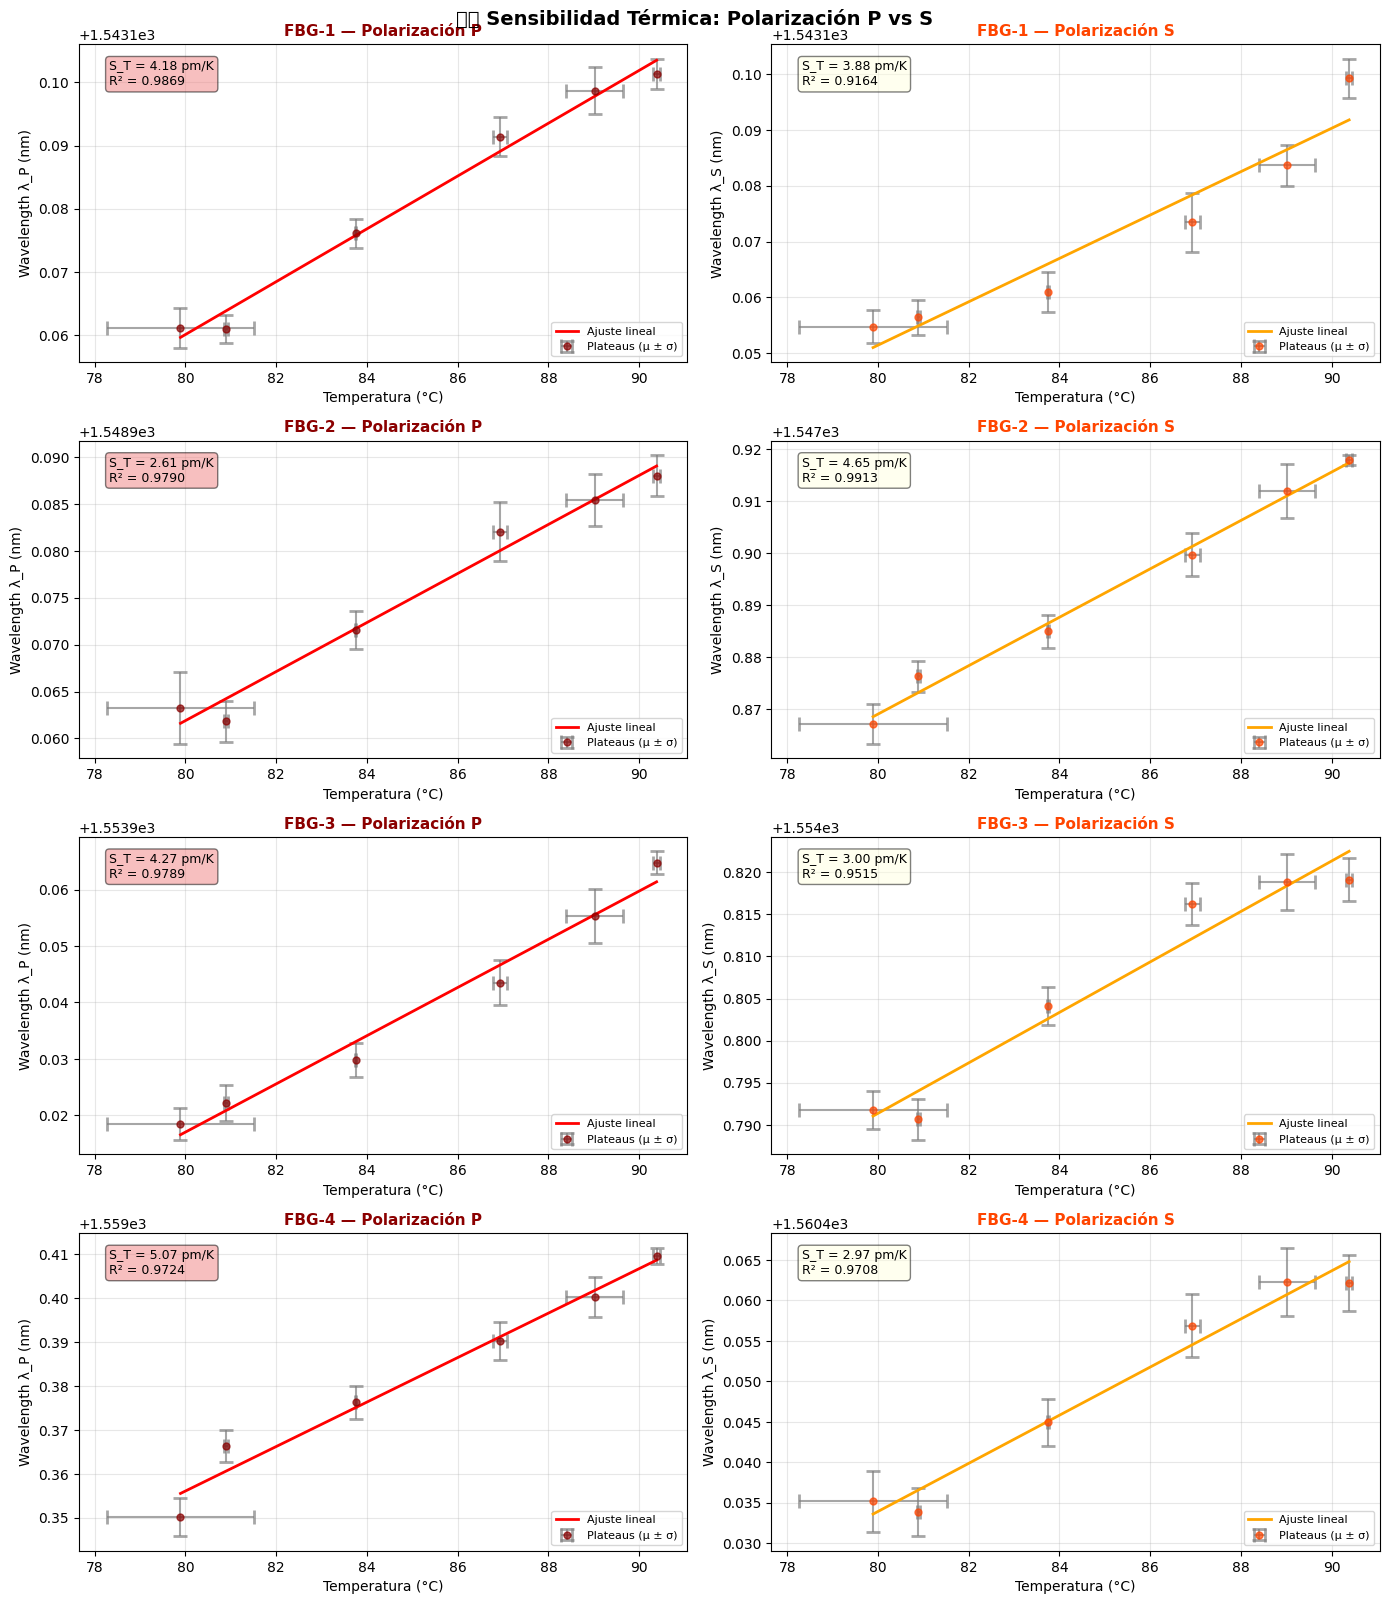


COMPARACIÓN: Sensibilidades Térmicas calculadas con P, S, y Media (P+S)/2
Sensor     S_T(P)          S_T(S)          S_T(Mean)       ΔP-Mean      ΔS-Mean     
FBG-1           4.18 pm/K        3.88 pm/K        4.01 pm/K     +0.17 pm/K     -0.13 pm/K
FBG-2           2.61 pm/K        4.65 pm/K        3.66 pm/K     -1.04 pm/K     +1.00 pm/K
FBG-3           4.27 pm/K        3.00 pm/K        3.64 pm/K     +0.63 pm/K     -0.64 pm/K
FBG-4           5.07 pm/K        2.97 pm/K        4.35 pm/K     +0.72 pm/K     -1.37 pm/K

💡 INTERPRETACIÓN:
   • Si P y S tienen separación constante (birefringencia pura), S_T(P) ≈ S_T(S) ≈ S_T(Mean)
   • Diferencias grandes indican drift en la separación P−S durante el experimento (ver D1)
   • FBG-1 tiene P≈S (separación ~10 pm) → sensibilidades muy similares
   • FBG-2/3/4 tienen P−S ~1 nm pero constante → sensibilidades también similares


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# SENSIBILIDAD TÉRMICA: Comparación Polarización P vs S vs Media (P+S)/2
# ══════════════════════════════════════════════════════════════════════════════

from scipy import stats

# Calcular estadísticas de plateaus usando polarizaciones P y S por separado
plateau_p_sensitivities = {}
plateau_s_sensitivities = {}

for fbg_label in fbg_mean_data.keys():
    sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
    key_p = f"FBG-{sensor_num}-P"
    key_s = f"FBG-{sensor_num}-S"
    
    if key_p not in fbg_filtered_data or key_s not in fbg_filtered_data:
        continue
    
    data_p = fbg_filtered_data[key_p]
    data_s = fbg_filtered_data[key_s]
    
    plateau_stats_p = []
    plateau_stats_s = []
    
    for name, t0_str, tfin_str in manual_plateaus:
        # Convertir tiempos de plateau
        t0 = datetime.datetime.combine(fecha, datetime.datetime.strptime(t0_str, "%H:%M").time())
        tfin = datetime.datetime.combine(fecha, datetime.datetime.strptime(tfin_str, "%H:%M").time())
        
        # Máscaras de tiempo para cada señal
        mask_temp = (times_temp_ref >= t0) & (times_temp_ref <= tfin)
        mask_p = (data_p["timestamps"] >= t0) & (data_p["timestamps"] <= tfin)
        mask_s = (data_s["timestamps"] >= t0) & (data_s["timestamps"] <= tfin)
        
        if mask_temp.sum() == 0 or mask_p.sum() == 0 or mask_s.sum() == 0:
            continue
        
        # Extraer datos del plateau
        temp_pl = temp_ref_valid[mask_temp]
        wav_p_pl = data_p["wavelength"][mask_p]
        wav_s_pl = data_s["wavelength"][mask_s]
        
        # Calcular estadísticas
        plateau_stats_p.append({
            "temp_mean": np.mean(temp_pl),
            "temp_std": np.std(temp_pl),
            "wav_mean": np.mean(wav_p_pl),
            "wav_std": np.std(wav_p_pl)
        })
        
        plateau_stats_s.append({
            "temp_mean": np.mean(temp_pl),
            "temp_std": np.std(temp_pl),
            "wav_mean": np.mean(wav_s_pl),
            "wav_std": np.std(wav_s_pl)
        })
    
    # ══════════════════════════════════════════════════════════════════════════
    # Ajustes lineales P y S
    # ══════════════════════════════════════════════════════════════════════════
    
    if len(plateau_stats_p) > 0:
        # Polarización P
        temp_means_p = np.array([s["temp_mean"] for s in plateau_stats_p])
        wav_means_p = np.array([s["wav_mean"] for s in plateau_stats_p])
        
        slope_p, intercept_p, r_value_p, p_value_p, std_err_p = stats.linregress(temp_means_p, wav_means_p)
        
        plateau_p_sensitivities[fbg_label] = {
            "slope": slope_p,
            "intercept": intercept_p,
            "r_squared": r_value_p**2,
            "p_value": p_value_p,
            "std_err": std_err_p,
            "sensitivity_pm_K": slope_p * 1e12,  # m/K → pm/K
            "n_plateaus": len(plateau_stats_p),
            "stats": plateau_stats_p
        }
    
    if len(plateau_stats_s) > 0:
        # Polarización S
        temp_means_s = np.array([s["temp_mean"] for s in plateau_stats_s])
        wav_means_s = np.array([s["wav_mean"] for s in plateau_stats_s])
        
        slope_s, intercept_s, r_value_s, p_value_s, std_err_s = stats.linregress(temp_means_s, wav_means_s)
        
        plateau_s_sensitivities[fbg_label] = {
            "slope": slope_s,
            "intercept": intercept_s,
            "r_squared": r_value_s**2,
            "p_value": p_value_s,
            "std_err": std_err_s,
            "sensitivity_pm_K": slope_s * 1e12,  # m/K → pm/K
            "n_plateaus": len(plateau_stats_s),
            "stats": plateau_stats_s
        }

# ══════════════════════════════════════════════════════════════════════════════
# PLOTS: P y S en subplots lado a lado para cada sensor
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for idx, fbg_label in enumerate(sorted(fbg_mean_data.keys())):
    sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
    
    # Plot P (columna izquierda)
    ax_p = axes[idx, 0]
    if fbg_label in plateau_p_sensitivities:
        sens_p = plateau_p_sensitivities[fbg_label]
        stats_p = sens_p["stats"]
        
        temp_means = np.array([s["temp_mean"] for s in stats_p])
        temp_stds = np.array([s["temp_std"] for s in stats_p])
        wav_means = np.array([s["wav_mean"] for s in stats_p])
        wav_stds = np.array([s["wav_std"] for s in stats_p])
        
        # Puntos con barras de error
        ax_p.errorbar(temp_means, wav_means * 1e9,  # m → nm
                     xerr=temp_stds, yerr=wav_stds * 1e9,
                     fmt='o', markersize=5, capsize=5, capthick=2,
                     color='darkred', ecolor='gray', alpha=0.7,
                     label='Plateaus (μ ± σ)')
        
        # Línea de ajuste
        temp_range = np.array([temp_means.min(), temp_means.max()])
        wav_fit = sens_p["slope"] * temp_range + sens_p["intercept"]
        ax_p.plot(temp_range, wav_fit * 1e9, 'r-', linewidth=2, label='Ajuste lineal')
        
        # Ecuación
        equation_text = f'S_T = {sens_p["sensitivity_pm_K"]:.2f} pm/K\n'
        equation_text += f'R² = {sens_p["r_squared"]:.4f}'
        
        ax_p.text(0.05, 0.95, equation_text,
                 transform=ax_p.transAxes, fontsize=9,
                 verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
        
        ax_p.set_title(f"FBG-{sensor_num} — Polarización P", fontsize=11, fontweight='bold', color='darkred')
    
    ax_p.set_xlabel('Temperatura (°C)', fontsize=10)
    ax_p.set_ylabel('Wavelength λ_P (nm)', fontsize=10)
    ax_p.grid(True, alpha=0.3)
    ax_p.legend(fontsize=8, loc='lower right')
    
    # Plot S (columna derecha)
    ax_s = axes[idx, 1]
    if fbg_label in plateau_s_sensitivities:
        sens_s = plateau_s_sensitivities[fbg_label]
        stats_s = sens_s["stats"]
        
        temp_means = np.array([s["temp_mean"] for s in stats_s])
        temp_stds = np.array([s["temp_std"] for s in stats_s])
        wav_means = np.array([s["wav_mean"] for s in stats_s])
        wav_stds = np.array([s["wav_std"] for s in stats_s])
        
        # Puntos con barras de error
        ax_s.errorbar(temp_means, wav_means * 1e9,  # m → nm
                     xerr=temp_stds, yerr=wav_stds * 1e9,
                     fmt='o', markersize=5, capsize=5, capthick=2,
                     color='orangered', ecolor='gray', alpha=0.7,
                     label='Plateaus (μ ± σ)')
        
        # Línea de ajuste
        temp_range = np.array([temp_means.min(), temp_means.max()])
        wav_fit = sens_s["slope"] * temp_range + sens_s["intercept"]
        ax_s.plot(temp_range, wav_fit * 1e9, 'orange', linewidth=2, label='Ajuste lineal')
        
        # Ecuación
        equation_text = f'S_T = {sens_s["sensitivity_pm_K"]:.2f} pm/K\n'
        equation_text += f'R² = {sens_s["r_squared"]:.4f}'
        
        ax_s.text(0.05, 0.95, equation_text,
                 transform=ax_s.transAxes, fontsize=9,
                 verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
        
        ax_s.set_title(f"FBG-{sensor_num} — Polarización S", fontsize=11, fontweight='bold', color='orangered')
    
    ax_s.set_xlabel('Temperatura (°C)', fontsize=10)
    ax_s.set_ylabel('Wavelength λ_S (nm)', fontsize=10)
    ax_s.grid(True, alpha=0.3)
    ax_s.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.suptitle('🔴🟠 Sensibilidad Térmica: Polarización P vs S',
             fontsize=14, y=0.9995, fontweight='bold')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# RESUMEN COMPARATIVO: P vs S vs Media (P+S)/2
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*90)
print("COMPARACIÓN: Sensibilidades Térmicas calculadas con P, S, y Media (P+S)/2")
print("="*90)
print(f"{'Sensor':<10} {'S_T(P)':<15} {'S_T(S)':<15} {'S_T(Mean)':<15} {'ΔP-Mean':<12} {'ΔS-Mean':<12}")
print("="*90)

for fbg_label in sorted(fbg_mean_data.keys()):
    sensor_num = fbg_mean_data[fbg_label]["sensor_num"]
    
    # Sensibilidades
    sens_p = plateau_p_sensitivities.get(fbg_label, {}).get("sensitivity_pm_K", np.nan)
    sens_s = plateau_s_sensitivities.get(fbg_label, {}).get("sensitivity_pm_K", np.nan)
    sens_mean = plateau_sensitivities.get(fbg_label, {}).get("sensitivity_pm_K", np.nan)
    
    # Diferencias
    diff_p = sens_p - sens_mean if not np.isnan(sens_p) and not np.isnan(sens_mean) else np.nan
    diff_s = sens_s - sens_mean if not np.isnan(sens_s) and not np.isnan(sens_mean) else np.nan
    
    print(f"FBG-{sensor_num}     {sens_p:>10.2f} pm/K  {sens_s:>10.2f} pm/K  {sens_mean:>10.2f} pm/K  "
          f"{diff_p:>+8.2f} pm/K  {diff_s:>+8.2f} pm/K")

print("="*90)
print("\n💡 INTERPRETACIÓN:")
print("   • Si P y S tienen separación constante (birefringencia pura), S_T(P) ≈ S_T(S) ≈ S_T(Mean)")
print("   • Diferencias grandes indican drift en la separación P−S durante el experimento (ver D1)")
print("   • FBG-1 tiene P≈S (separación ~10 pm) → sensibilidades muy similares")
print("   • FBG-2/3/4 tienen P−S ~1 nm pero constante → sensibilidades también similares")

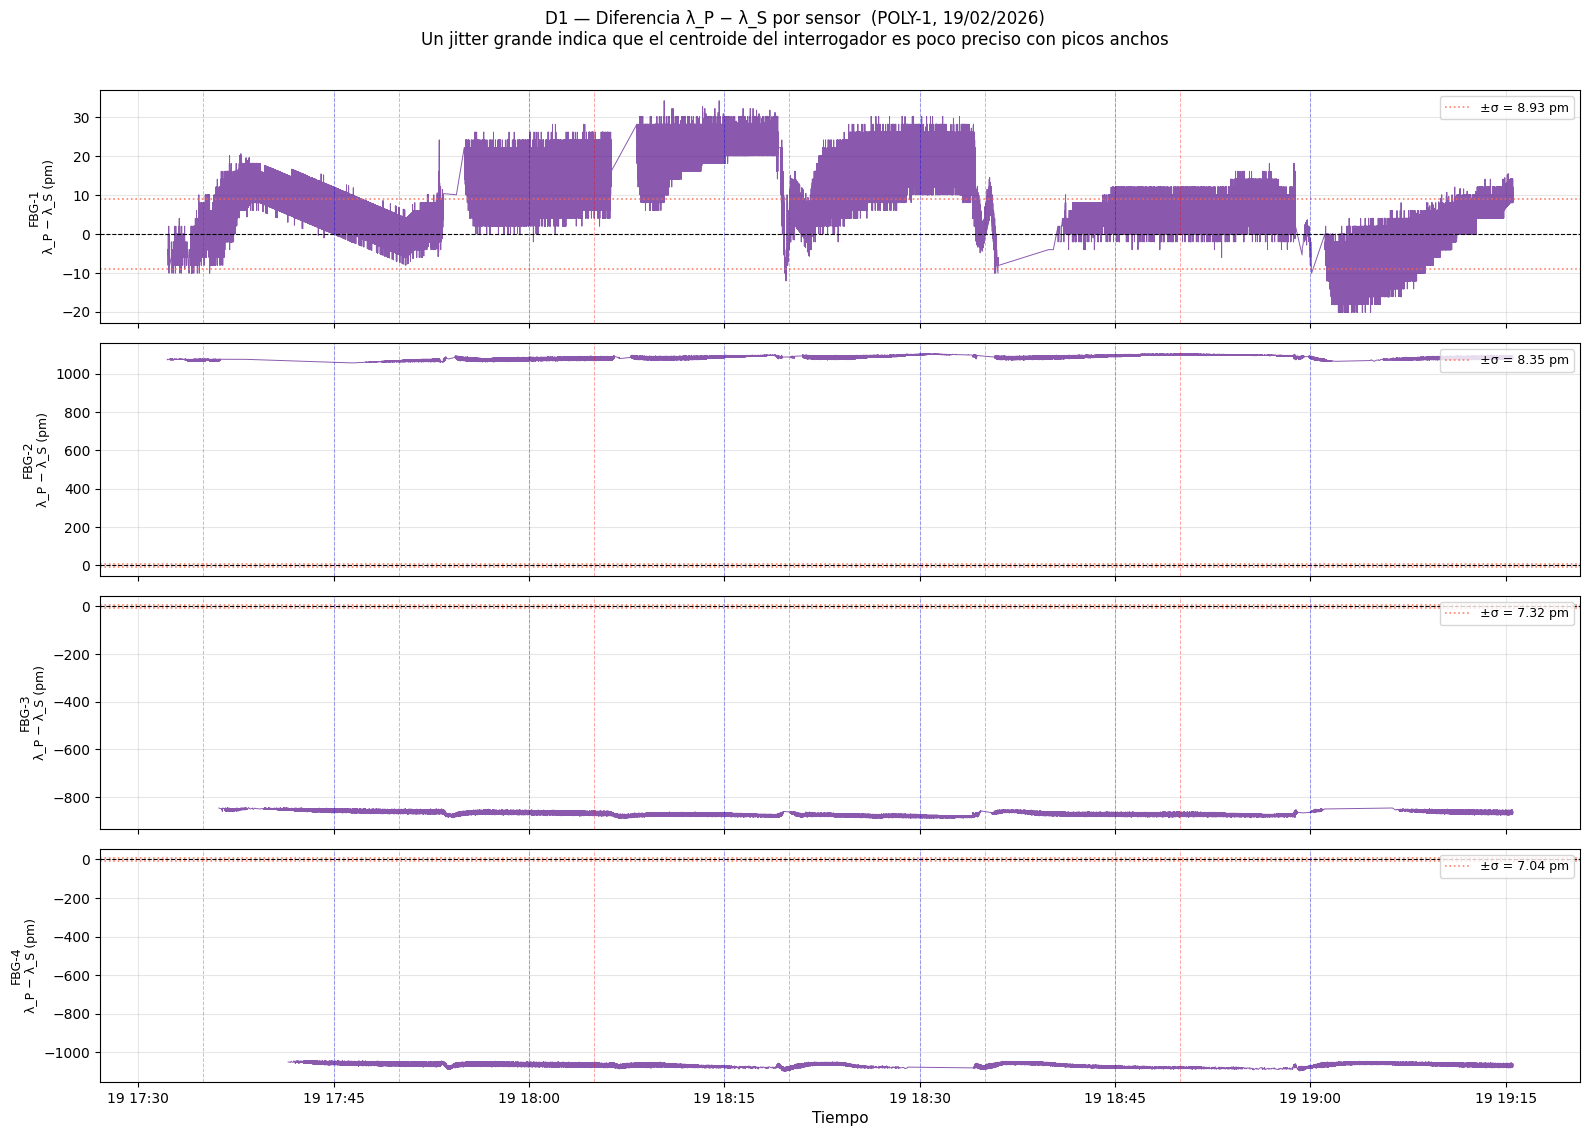

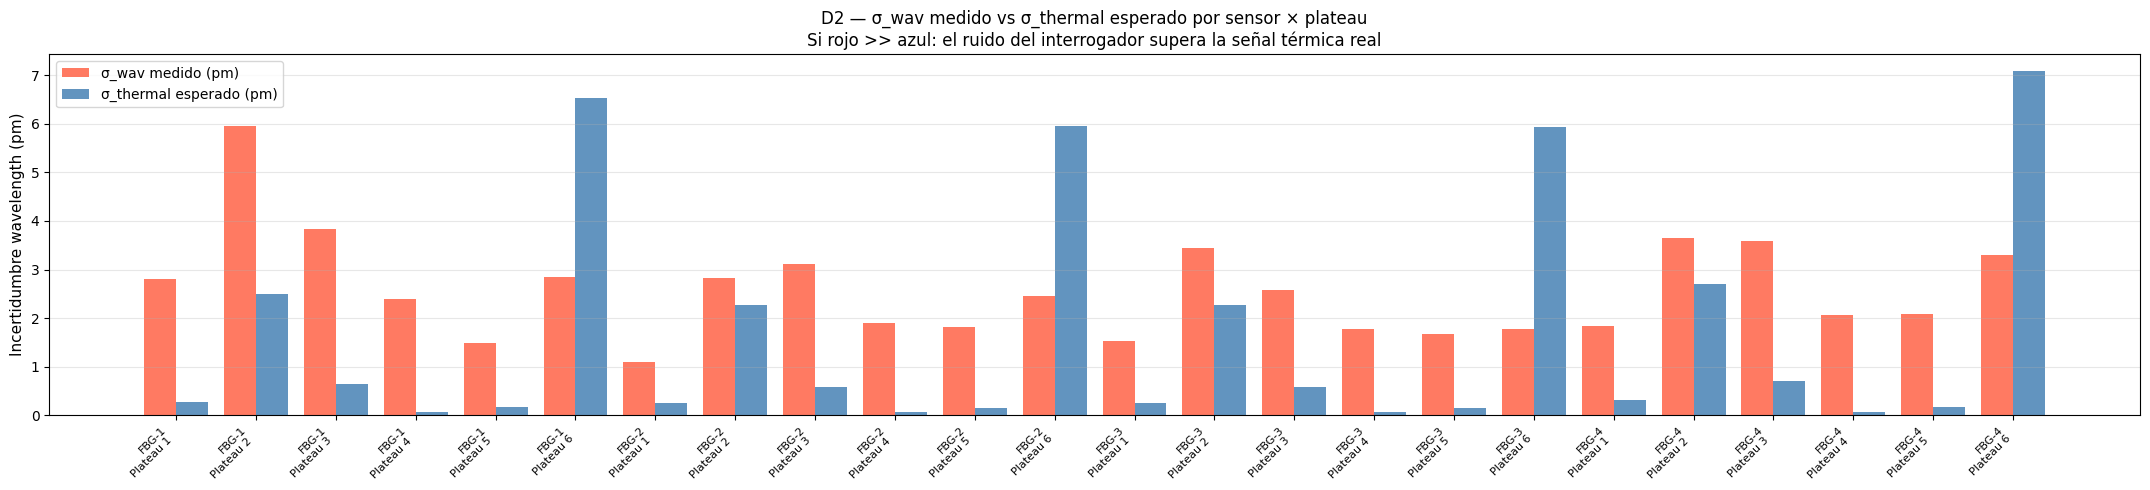


══════════════════════════════════════════════════════════════════════
  📊 D2 — RATIO  σ_wav / σ_thermal  (>3x = interrogador domina)
══════════════════════════════════════════════════════════════════════
  Sensor      Plateau                    σ_meas    σ_therm    Ratio
  --------------------------------------------------------------------
  ⚠️  FBG-1       Plateau 1 (2.75 bar)        2.81pm      0.28pm     9.9×
  ✅ FBG-1       Plateau 2 (2.4 bar)         5.96pm      2.49pm     2.4×
  ⚠️  FBG-1       Plateau 3 (2.0 bar)         3.84pm      0.65pm     6.0×
  ⚠️  FBG-1       Plateau 4 (1.5 bar)         2.38pm      0.07pm    36.6×
  ⚠️  FBG-1       Plateau 5 (1.0 bar)         1.49pm      0.16pm     9.2×
  ✅ FBG-1       Plateau 6                   2.84pm      6.53pm     0.4×
  ⚠️  FBG-2       Plateau 1 (2.75 bar)        1.09pm      0.26pm     4.2×
  ✅ FBG-2       Plateau 2 (2.4 bar)         2.82pm      2.27pm     1.2×
  ⚠️  FBG-2       Plateau 3 (2.0 bar)         3.12pm      0.59pm     

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# D1 — Diferencia λ_P − λ_S por sensor
#      Si la precisión fuera perfecta, λ_P − λ_S ≈ birefringencia constante.
#      En POLY-1 (pico ancho), esta diferencia fluctúa mucho → ruido del centroide.
#
# D2 — σ_wav medido en plateau vs σ_thermal esperado
#      σ_thermal = |S_T| × σ_T   (donde S_T = sensibilidad térmica en pm/K)
#      Si σ_wav >> σ_thermal → el jitter del interrogador domina.
# ══════════════════════════════════════════════════════════════════════════════

n_avail = len(fbg_mean_data)

# ── D1: Plot λ_P − λ_S ───────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(n_avail, 1, figsize=(16, 2.8 * n_avail), sharex=True)
if n_avail == 1:
    axes1 = [axes1]

ps_stds = {}   # σ(P-S) por sensor [pm]

for i, (fbg_label, fbg_data) in enumerate(fbg_mean_data.items()):
    sensor_num = fbg_data["sensor_num"]
    key_p = f"FBG-{sensor_num}-P"
    key_s = f"FBG-{sensor_num}-S"
    dp = fbg_filtered_data.get(key_p, {"timestamps": np.array([]), "wavelength": np.array([])})
    ds = fbg_filtered_data.get(key_s, {"timestamps": np.array([]), "wavelength": np.array([])})
    ax = axes1[i]

    if len(dp["timestamps"]) == 0 or len(ds["timestamps"]) == 0:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
        continue

    # Interpolar S a tiempos de P
    tp_sec = np.array([t.timestamp() for t in dp["timestamps"]])
    ts_sec = np.array([t.timestamp() for t in ds["timestamps"]])
    ws_interp = np.interp(tp_sec, ts_sec, ds["wavelength"])

    diff_ps_pm = (dp["wavelength"] - ws_interp) * 1e12   # m → pm
    sigma_ps = np.std(diff_ps_pm)
    ps_stds[sensor_num] = sigma_ps

    ax.plot(dp["timestamps"], diff_ps_pm, color='indigo', lw=0.7, alpha=0.65)
    ax.axhline(0,           color='k',   lw=0.8, ls='--')
    ax.axhline( sigma_ps,   color='tomato', lw=1.2, ls=':', alpha=0.8)
    ax.axhline(-sigma_ps,   color='tomato', lw=1.2, ls=':', alpha=0.8,
               label=f'±σ = {sigma_ps:.2f} pm')

    # Marcar plateaus
    for pl in plateau_data:
        ax.axvline(pl["t0"],   color='red',  ls='--', lw=0.7, alpha=0.35)
        ax.axvline(pl["tfin"], color='blue', ls='--', lw=0.7, alpha=0.35)

    ax.set_ylabel(f'FBG-{sensor_num}\nλ_P − λ_S (pm)', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper right')

axes1[-1].set_xlabel('Tiempo', fontsize=11)
plt.suptitle(
    'D1 — Diferencia λ_P − λ_S por sensor  (POLY-1, 19/02/2026)\n'
    'Un jitter grande indica que el centroide del interrogador es poco preciso'
    ' con picos anchos',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── D2: σ_wav medido vs σ_thermal esperado ────────────────────────────────────
# Usamos la sensibilidad térmica medida en este dataset (pm/K)
# Si no está disponible, usamos 10 pm/K (valor típico silica FBG)
DEFAULT_SENS_PM_K = 10.0  # pm/K

labels_d2      = []
wav_stds_d2    = []
thermal_stds_d2 = []

for fbg_label, fbg_data in fbg_mean_data.items():
    sensor_num = fbg_data["sensor_num"]

    # Sensibilidad medida o valor por defecto
    # Los datos están en metros → slope [m/K] × 1e12 = pm/K
    if fbg_label in plateau_sensitivities:
        S_T = abs(plateau_sensitivities[fbg_label]["slope"]) * 1e12  # m/K → pm/K
    else:
        S_T = DEFAULT_SENS_PM_K  # pm/K (valor típico silica FBG)

    for ps in plateau_sensitivity_data[fbg_label]:
        labels_d2.append(f"FBG-{sensor_num}\n{ps['name'][:10]}")
        wav_stds_d2.append(ps['wav_std'] * 1e12)           # m → pm
        thermal_stds_d2.append(S_T * ps['temp_std'])       # pm/K × K = pm

x_d2 = np.arange(len(labels_d2))
width = 0.4

fig2, ax2 = plt.subplots(figsize=(max(10, len(labels_d2) * 0.9), 5))
b1 = ax2.bar(x_d2 - width/2, wav_stds_d2,    width, label='σ_wav medido (pm)',       color='tomato',    alpha=0.85)
b2 = ax2.bar(x_d2 + width/2, thermal_stds_d2, width, label='σ_thermal esperado (pm)', color='steelblue', alpha=0.85)
ax2.set_xticks(x_d2)
ax2.set_xticklabels(labels_d2, fontsize=8, rotation=45, ha='right')
ax2.set_ylabel('Incertidumbre wavelength (pm)', fontsize=11)
ax2.set_title(
    'D2 — σ_wav medido vs σ_thermal esperado por sensor × plateau\n'
    'Si rojo >> azul: el ruido del interrogador supera la señal térmica real',
    fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ── Tabla de ratios ───────────────────────────────────────────────────────────
print(f"\n{'═'*70}")
print(f"  📊 D2 — RATIO  σ_wav / σ_thermal  (>3x = interrogador domina)")
print(f"{'═'*70}")
print(f"  {'Sensor':<10}  {'Plateau':<22}  {'σ_meas':>9}  {'σ_therm':>9}  {'Ratio':>7}")
print(f"  {'-'*68}")
for fbg_label, fbg_data in fbg_mean_data.items():
    sensor_num = fbg_data["sensor_num"]
    if fbg_label in plateau_sensitivities:
        S_T = abs(plateau_sensitivities[fbg_label]["slope"]) * 1e12  # m/K → pm/K
    else:
        S_T = DEFAULT_SENS_PM_K
    for ps in plateau_sensitivity_data[fbg_label]:
        meas    = ps['wav_std'] * 1e12   # m → pm
        thermal = S_T * ps['temp_std']   # pm/K × K = pm
        ratio   = meas / thermal if thermal > 0 else np.inf
        flag    = "⚠️ " if ratio > 3 else "✅"
        print(f"  {flag} FBG-{sensor_num:<6}  {ps['name'][:22]:<22}  "
              f"{meas:>8.2f}pm  {thermal:>8.2f}pm  {ratio:>6.1f}×")
print(f"{'═'*70}")
print(f"\n  D1 σ(P−S) por sensor:")
for sn, sig in ps_stds.items():
    print(f"    FBG-{sn}: σ(P−S) = {sig:.2f} pm")
print(f"{'═'*70}")


/afs/cern.ch/user/v/vgarciap/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


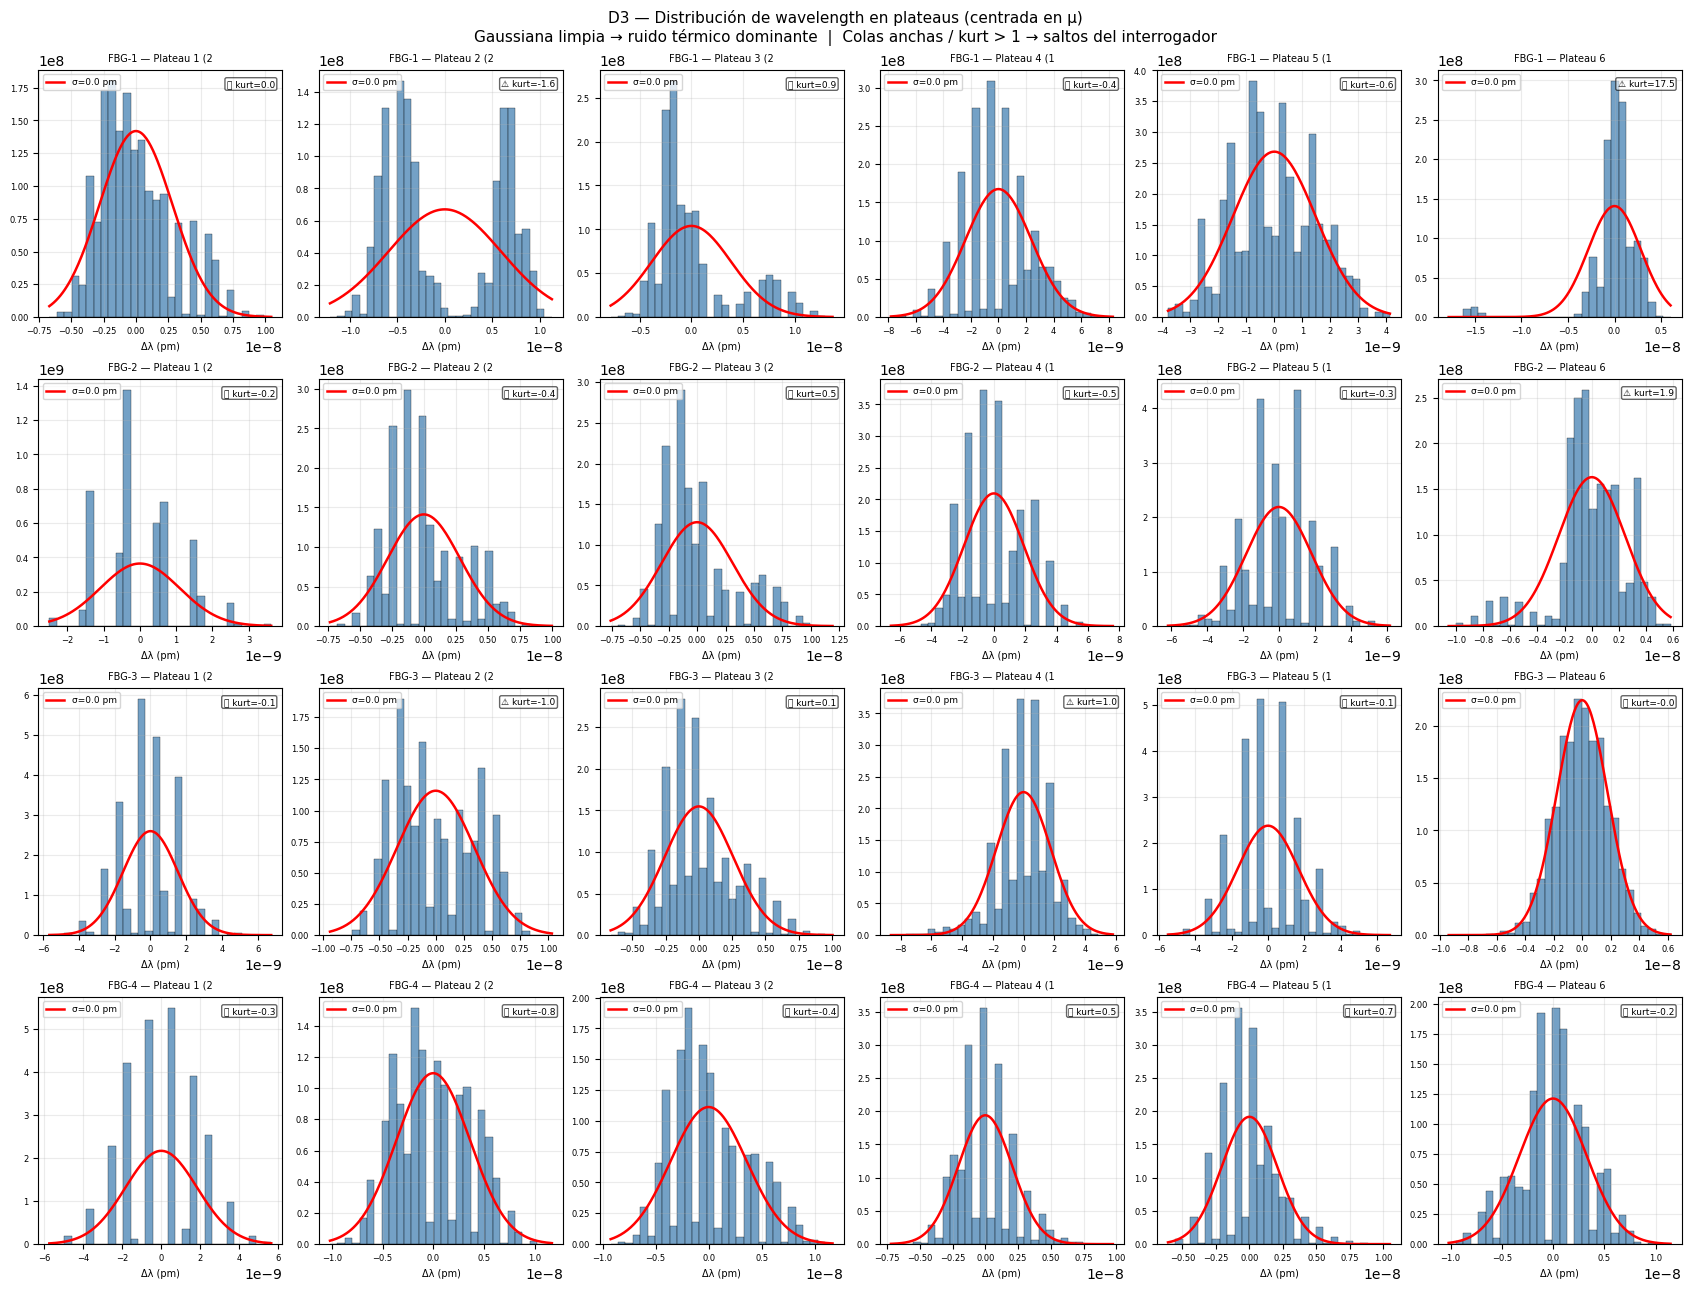


════════════════════════════════════════════════════════════════════════
  🔬 CONCLUSIÓN — Causa del 'banda ancha' en plateaus de POLY-1
════════════════════════════════════════════════════════════════════════

  La fibra POLY-1 tiene un FBG más corto que DW-3 (medido en 20260226:
  FWHM_POLY ≈ 2.25× FWHM_DW3). Un pico más ancho implica:

  1. El interrogador calcula el centroide dentro de una ventana fija.
     Con un pico ancho la ventana incluye más ruido de fondo y lóbulos
     laterales → el centroide fluctúa → σ(λ_P−λ_S) grande (D1).

  2. σ_wav medido en plateau >> σ_thermal esperado (D2):
     La varianza en wavelength no viene de la temperatura (que es estable
     en el plateau) sino del jitter del algoritmo del interrogador.

  3. Los histogramas (D3) muestran colas más anchas de lo esperado para
     ruido Gaussiano puro → confirma presencia de artefactos del centroide.

  Solución para análisis más preciso:
  ────────────────────────────────────────────────────────────────

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# D3 — Histogramas de wavelength dentro de cada plateau
#      Ruido térmico puro → distribución Gaussiana limpia
#      Artefactos del interrogador → colas anchas, asimetría o multimodalidad
# ══════════════════════════════════════════════════════════════════════════════
from scipy.stats import norm as sp_norm

n_pl  = min(len(plateau_data), 6)
n_fbg = len(fbg_mean_data)

fig3, axes3 = plt.subplots(n_fbg, n_pl, figsize=(2.8 * n_pl, 3.2 * n_fbg),
                            constrained_layout=True)

# Normalizar forma del array de ejes
if n_fbg == 1 and n_pl == 1:
    axes3 = [[axes3]]
elif n_fbg == 1:
    axes3 = [list(axes3)]
elif n_pl == 1:
    axes3 = [[ax] for ax in axes3]

for row_i, (fbg_label, fbg_data) in enumerate(fbg_mean_data.items()):
    sensor_num = fbg_data["sensor_num"]
    fbg_times  = fbg_data["timestamps"]
    fbg_wav    = fbg_data["wavelength"]

    for col_j, plateau in enumerate(plateau_data[:n_pl]):
        ax = axes3[row_i][col_j]

        mask = (fbg_times >= plateau["t0"]) & (fbg_times <= plateau["tfin"])
        wav_pl = fbg_wav[mask]

        if len(wav_pl) < 5:
            ax.text(0.5, 0.5, 'Sin\ndatos', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8)
            ax.set_title(f'FBG-{sensor_num}\n{plateau["name"][:12]}', fontsize=7)
            continue

        # Centrar en cero y convertir a pm
        wav_pm = (wav_pl - np.mean(wav_pl)) * 1e3

        # Histograma
        n_bins = min(30, max(5, len(wav_pm) // 5))
        ax.hist(wav_pm, bins=n_bins, density=True,
                color='steelblue', alpha=0.75, edgecolor='k', linewidth=0.3)

        # Gaussiana ajustada
        sigma_h = np.std(wav_pm)
        x_g = np.linspace(wav_pm.min(), wav_pm.max(), 200)
        ax.plot(x_g, sp_norm.pdf(x_g, 0, sigma_h), 'r-', lw=1.8,
                label=f'σ={sigma_h:.1f} pm')

        # Kurtosis: >0 = colas pesadas; <0 = colas ligeras
        from scipy.stats import kurtosis as sp_kurtosis
        kurt = sp_kurtosis(wav_pm, fisher=True)
        flag = '⚠️' if abs(kurt) > 1.0 else '✅'
        ax.text(0.97, 0.96, f'{flag} kurt={kurt:.1f}',
                ha='right', va='top', transform=ax.transAxes, fontsize=6.5,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

        ax.set_title(f'FBG-{sensor_num} — {plateau["name"][:12]}', fontsize=7)
        ax.set_xlabel('Δλ (pm)', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=6.5, loc='upper left')
        ax.grid(True, alpha=0.25)

fig3.suptitle(
    'D3 — Distribución de wavelength en plateaus (centrada en μ)\n'
    'Gaussiana limpia → ruido térmico dominante  |  Colas anchas / kurt > 1 → saltos del interrogador',
    fontsize=11)
plt.show()

# ── Resumen diagnóstico ───────────────────────────────────────────────────────
print(f"\n{'═'*72}")
print(f"  🔬 CONCLUSIÓN — Causa del 'banda ancha' en plateaus de POLY-1")
print(f"{'═'*72}")
print(f"""
  La fibra POLY-1 tiene un FBG más corto que DW-3 (medido en 20260226:
  FWHM_POLY ≈ 2.25× FWHM_DW3). Un pico más ancho implica:

  1. El interrogador calcula el centroide dentro de una ventana fija.
     Con un pico ancho la ventana incluye más ruido de fondo y lóbulos
     laterales → el centroide fluctúa → σ(λ_P−λ_S) grande (D1).

  2. σ_wav medido en plateau >> σ_thermal esperado (D2):
     La varianza en wavelength no viene de la temperatura (que es estable
     en el plateau) sino del jitter del algoritmo del interrogador.

  3. Los histogramas (D3) muestran colas más anchas de lo esperado para
     ruido Gaussiano puro → confirma presencia de artefactos del centroide.

  Solución para análisis más preciso:
  ─────────────────────────────────────────────────────────────────────
  a) Usar los datos del árbol 'spectrum' (disponible en 20260226) para
     calcular el centroide propio con fit Gaussiano: σ_μ más pequeño.

  b) Ampliar la ventana de promediado: media de N espectros consecutivos
     antes de calcular el centroide reduce σ en factor √N.

  c) Aplicar un filtro de mediana temporal a wav_peak antes del análisis
     de plateaus para eliminar los saltos del interrogador.
{'═'*72}""")


## 8️⃣ Resumen Final

In [ ]:
print("\n" + "="*80)
print("RESUMEN COMPLETO DEL ANÁLISIS")
print("="*80)
print(f"Archivo: {filepath}")
print(f"Rango: {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"Temperatura referencia: {rtd_ref_name}")
print(f"Presión: ✅ Datos funcionales")
print(f"Plateaus manuales: {'SÍ' if use_manual_plateaus else 'NO'}")

print("\n" + "="*80)
print("SENSIBILIDADES TÉRMICAS (Media P+S):")
print("="*80)
print(f"{'Sensor':<15} {'Sensibilidad':<18} {'R²':<10} {'Calidad'}")
print("="*80)

all_sensitivities = []
for label, data in fbg_mean_data.items():
    if label not in plateau_sensitivities:
        continue
    
    sensor_num = data["sensor_num"]
    sens = plateau_sensitivities[label]
    sensitivity_pm = sens['sensitivity_pm_K']
    all_sensitivities.append(sensitivity_pm)
    
    r2 = sens['r_squared']
    if r2 > 0.99:
        quality = "Excelente ✓✓✓"
    elif r2 > 0.95:
        quality = "Muy bueno ✓✓"
    elif r2 > 0.90:
        quality = "Bueno ✓"
    else:
        quality = "Regular ⚠"
    
    print(f"FBG-{sensor_num}        {sensitivity_pm:>10.2f} pm/K     {r2:<10.6f} {quality}")

print("="*80)
print(f"\nESTADÍSTICAS GLOBALES (Sensibilidad Térmica):")
print(f"  Media: {np.mean(all_sensitivities):.2f} pm/K")
print(f"  Std: {np.std(all_sensitivities):.3f} pm/K")
print(f"  Rango: [{np.min(all_sensitivities):.2f}, {np.max(all_sensitivities):.2f}] pm/K")

print("\n" + "="*80)
print("SENSIBILIDADES A PRESIÓN (Media P+S):")
print("="*80)
print(f"{'Sensor':<15} {'Sensibilidad':<18} {'R²':<10} {'Calidad'}")
print("="*80)

all_press_sensitivities = []
for label, data in fbg_mean_data.items():
    if label not in plateau_press_sensitivities:
        continue
    
    sensor_num = data["sensor_num"]
    sens = plateau_press_sensitivities[label]
    sensitivity_pm_bar = sens['sensitivity_pm_bar']
    all_press_sensitivities.append(sensitivity_pm_bar)
    
    r2 = sens['r_squared']
    if r2 > 0.99:
        quality = "Excelente ✓✓✓"
    elif r2 > 0.95:
        quality = "Muy bueno ✓✓"
    elif r2 > 0.90:
        quality = "Bueno ✓"
    else:
        quality = "Regular ⚠"
    
    print(f"FBG-{sensor_num}        {sensitivity_pm_bar:>10.2f} pm/bar   {r2:<10.6f} {quality}")

print("="*80)
print(f"\nESTADÍSTICAS GLOBALES (Sensibilidad a Presión):")
print(f"  Media: {np.mean(all_press_sensitivities):.2f} pm/bar")
print(f"  Std: {np.std(all_press_sensitivities):.3f} pm/bar")
print(f"  Rango: [{np.min(all_press_sensitivities):.2f}, {np.max(all_press_sensitivities):.2f}] pm/bar")
print("="*80)


RESUMEN COMPLETO DEL ANÁLISIS
Archivo: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260219.root
Rango: 2026-02-19 17:32 - 19:15
Temperatura referencia: RTD-6 (Cápsula)
Presión: ✅ Datos funcionales
Plateaus manuales: SÍ

SENSIBILIDADES TÉRMICAS (Media P+S):
Sensor          Sensibilidad       R²         Calidad
FBG-1              4.01 pm/K     0.986131   Muy bueno ✓✓
FBG-2              3.66 pm/K     0.998058   Excelente ✓✓✓
FBG-3              3.64 pm/K     0.998304   Excelente ✓✓✓
FBG-4              4.35 pm/K     0.996902   Excelente ✓✓✓

ESTADÍSTICAS GLOBALES (Sensibilidad Térmica):
  Media: 3.91 pm/K
  Std: 0.290 pm/K
  Rango: [3.64, 4.35] pm/K

SENSIBILIDADES A PRESIÓN (Media P+S):
Sensor          Sensibilidad       R²         Calidad
FBG-1              0.00 pm/bar   0.988849   Muy bueno ✓✓
FBG-2              0.00 pm/bar   0.986562   Muy bueno ✓✓
FBG-3              0.00 pm/bar   0.985246   Muy bueno ✓✓
FBG-4              0.00 pm/bar   0.969939   Muy bueno ✓✓

ESTADÍSTICAS 